<U+0001F539> <U+6587><U+5B57><U+5217><U+3092><U+542B><U+3080><U+5909><U+6570><U+FF08>NA<U+4EE5><U+5916><U+FF09>:
<U+30FB>namessolvent1:  DCM, CF, THF, oDCB, CB 
<U+30FB>SMILESnM:  O=C(OC)CCCC1(C2=CC=CC=C2)C34C15C(C6=C78)=C9C(C%10=C%11C%12=C%13C%14=C%15%16)=C5C%17=C(C%10=C%12%18)C%19=C%20C%18=C%14C%21=C%20C%22=C%23C%19=C%17C3=C%24C%25=C4C6=C%26C7=C%27C%28=C%29C8=C9C%11=C%29C%13=C%15C%28=C%30C%27=C%31C%26=C%25C%32=C%31C%33=C%30C%16=C%21C%33=C%22C%32=C%24%23, O=C(OC)CCCC1(C2=CC=CC=C2)C3(C4=C5C6=C7C8=C9C%10=C6C%11=C4C%12=C%13C%11=C%14C%10=C%15C9=C%16%17)C1%18C%12=C%19C(C%20=C%21C%22=C%23%24)=C%18C%25=C(C%20=C%22%26)C%27=C%28C%26=C(C%29=C%30%31)C%24=C%30C%32=C%33C%23=C%34C%21=C%19C%13=C%34C%14=C%33C%15=C%32C%17=C%31C%35=C%16C8=C%36C7=C%37C5=C3C%25=C%27C%37=C%38C%28=C%29C%35=C%38%36, CCCCCCC1=C/C(N=C1/C=C\C2=C(CCCCCC)C(C3=CC=CC(C4=C(C5=N/C(C(CCCCCC)=C5)=C\C=C(N/6)\C(CCCCCC)=CC6=C7C=C(CCCCCC)C(/C=C\8)=N\7)NC8=C4CCCCCC)=C3)=C9N2)=C(C=C/%10CCCCCC)\NC%10=C/C=C%11N=C9C=C\%11CCCCCC, CCCCCCC1=C/C(N

Warning message in cor(numData_scaled, use = "pairwise.complete.obs"):
"the standard deviation is zero"



<U+0001F539> Processing index: silhouette 
<U+2705> Best number of clusters (silhouette) = 2

<U+0001F539> Processing index: dunn 
<U+2705> Best number of clusters (dunn) = 2


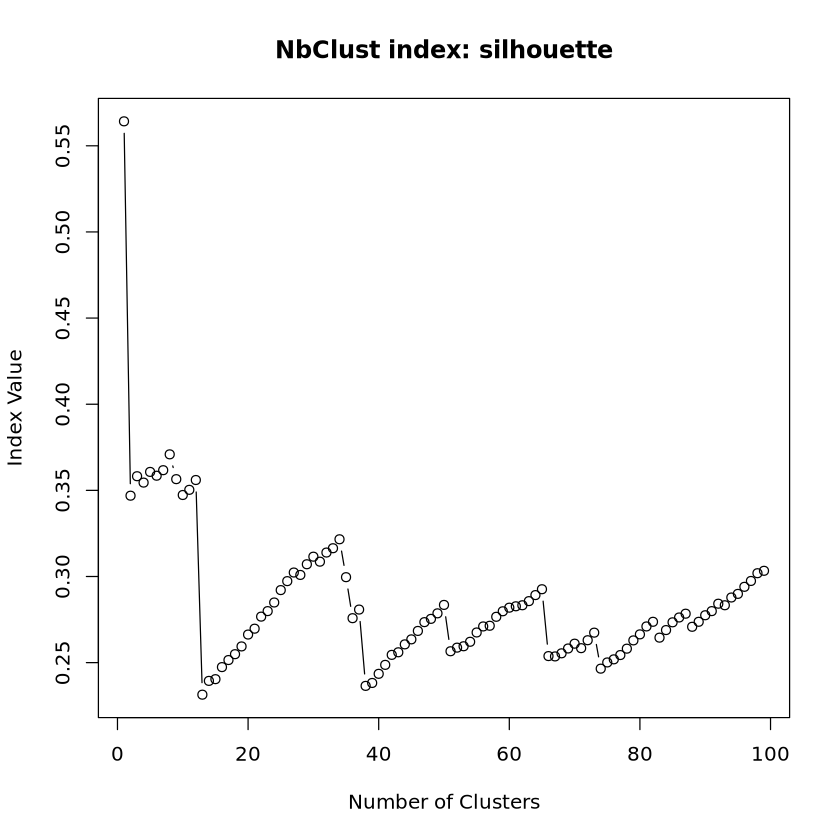


<U+0001F539> Processing index: gap 
<U+2705> Best number of clusters (gap) = 2


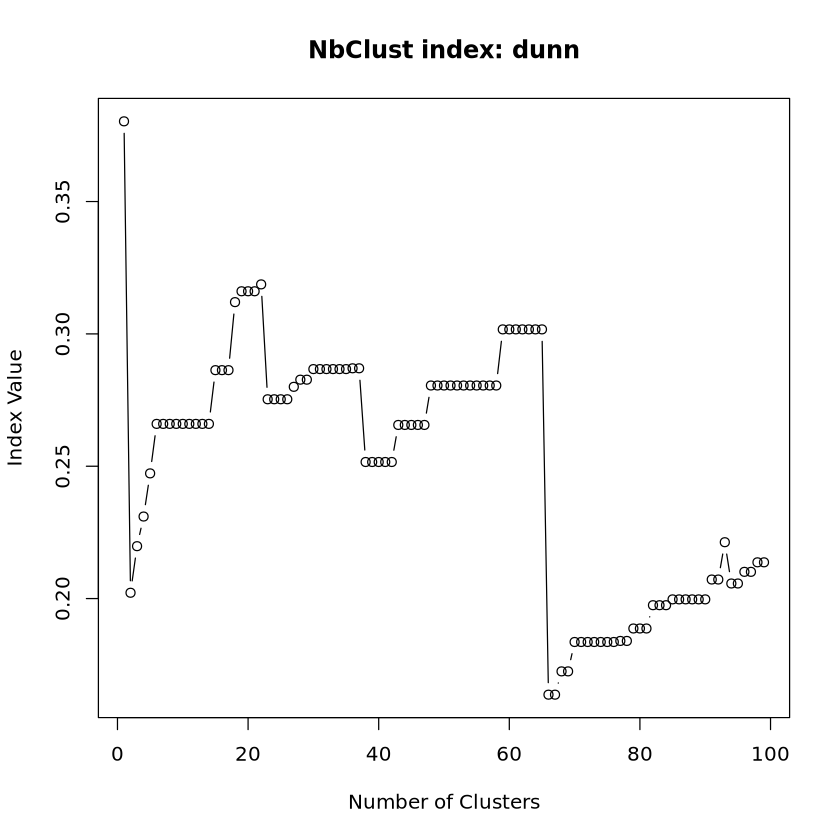


<U+0001F539> Processing index: ch 
<U+2705> Best number of clusters (ch) = 2


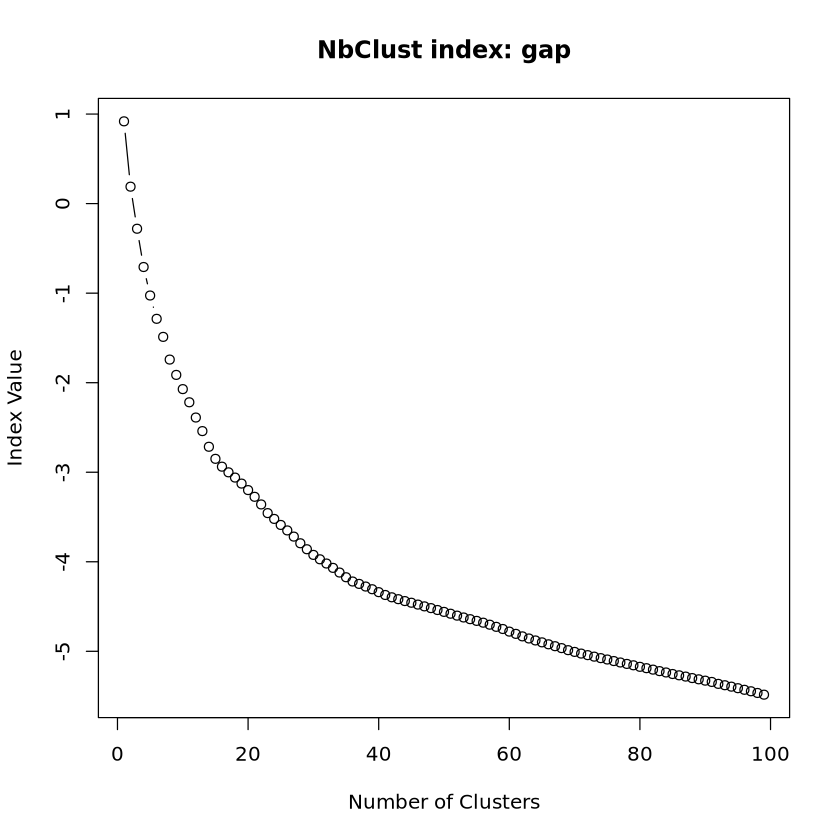


<U+0001F539> Processing index: db 
<U+2705> Best number of clusters (db) = 92


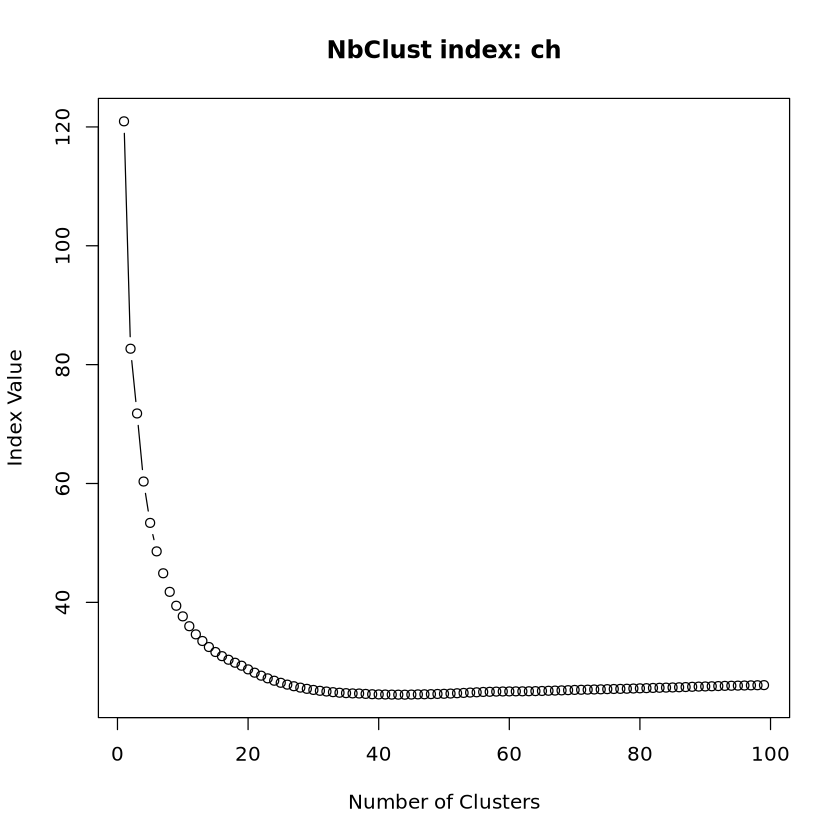


<U+0001F539> Processing index: ptbiserial 
<U+2705> Best number of clusters (ptbiserial) = 13


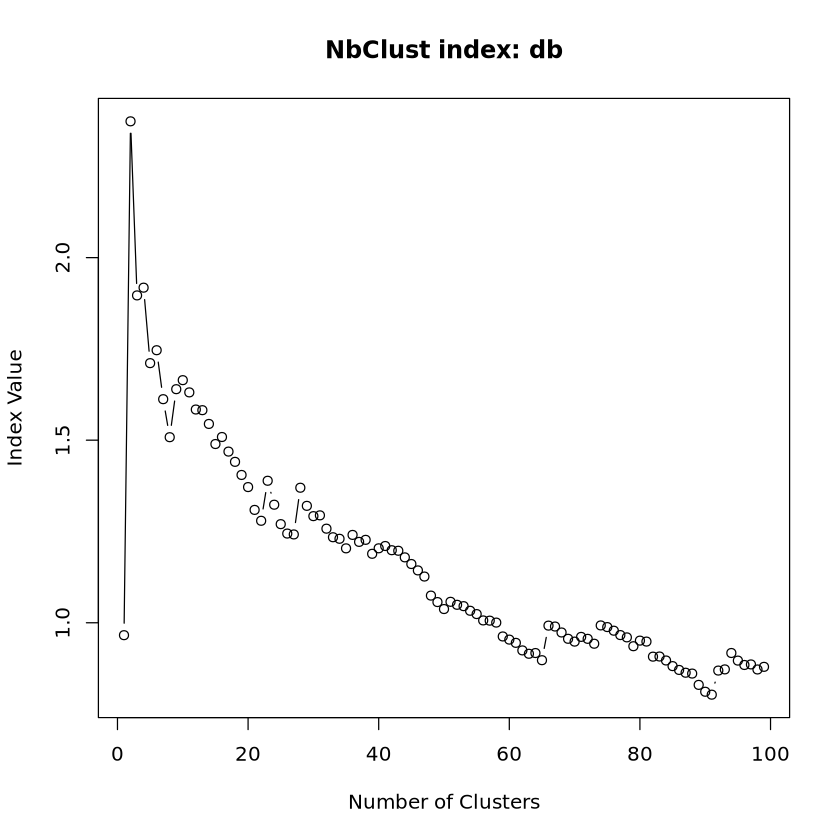

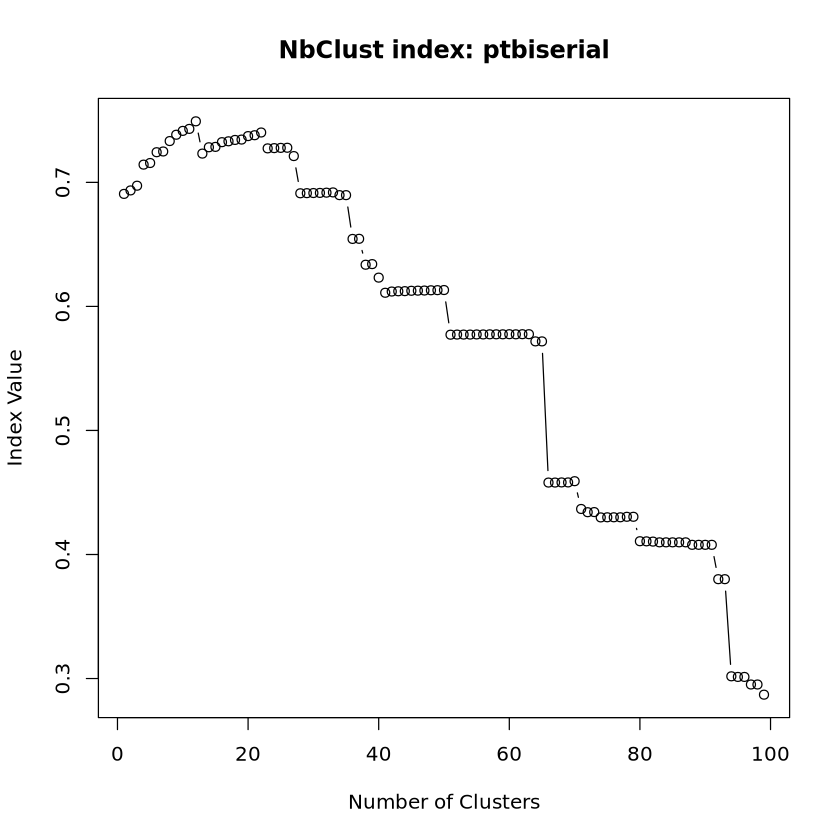

In [15]:
# # --- パッケージの読み込み・インストール ---
# if (!require(NbClust)) {
#   install.packages("NbClust")
#   library(NbClust)
# }

# # --- データの読み込み ---
# # ifname <- "DataMerge20211220oh.csv"
# ifname <- "DataMerge20211220oh_20250717_OH.csv"
# readData <- read.delim(ifname, header = TRUE, sep = ",", row.names = 1, as.is = TRUE, strip.white = FALSE)

# # 目的変数を除いたデータフレームを作成
# target_vars <- c("PCEmax", "Jsc", "Voc", "FF")

# expl_vars <- readData[, !(colnames(readData) %in% target_vars)]
# removed_targets <- colnames(readData)[colnames(readData) %in% target_vars]

# # --- 1. 文字列を含む変数を検出（NA以外の文字列） ---
# is_char_with_nonNA <- sapply(expl_vars, function(col) {
#   any(grepl("[A-Za-z]", col) & col != "NA", na.rm = TRUE)
# })
# char_vars <- names(expl_vars)[is_char_with_nonNA]

# # --- 2. 該当する変数と例データの表示 ---
# cat("🔹 文字列を含む変数（NA以外）:\n")
# for (var in char_vars) {
#   sample_vals <- unique(na.omit(expl_vars[[var]]))
#   cat(paste0("・", var, ": "), paste(head(sample_vals, 5), collapse = ", "), "\n")
# }

# # --- 3. 該当変数を除去し、数値データのみ残す ---
# expl_vars_clean <- expl_vars[, !colnames(expl_vars) %in% char_vars]
# removed_char_vars <- char_vars

# # # --- 数値変数の抽出 ---
# # is_numeric <- sapply(expl_vars, is.numeric)
# # numData <- expl_vars[, is_numeric]
# # removed_non_numeric <- colnames(expl_vars)[!is_numeric]

# # --- 標準偏差が0の列を除去 ---
# sd_nonzero <- apply(numData, 2, sd, na.rm = TRUE) != 0
# numData_final <- numData[, sd_nonzero]
# removed_sd_zero <- colnames(numData)[!sd_nonzero]

# # --- スケーリング ---
# numData_scaled <- scale(numData_final)

# # --- 除去変数の記録と出力 ---
# removal_log <- data.frame(
#   Step = c(
#     rep("Target variable", length(removed_targets)),
#     rep("Non-numeric variable", length(removed_char_vars)),
#     rep("Zero SD variable", length(removed_sd_zero))
#   ),
#   Removed_Variable = c(removed_targets, removed_char_vars, removed_sd_zero)
# )

# # --- 表示と保存 ---
# cat("🔹 Summary of removed variables:\n")
# print(removal_log)

# write.csv(removal_log, file = "RemovedVariablesSummary.csv", row.names = FALSE)

# # --- 相関距離行列の作成 ---
# corData <- cor(numData_scaled, use = "pairwise.complete.obs")
# corData[is.na(corData)] <- 0
# ddata <- dist(1 - abs(corData))  # absをとることで相関の強さ重視

# # --- MDS（主座標分析） ---
# Nvars <- ncol(numData)
# kmax <- min(Nvars - 1, 100)  # 最大クラスタ数を30に制限
# if (kmax < 2) stop("⚠️ 変数数が少なすぎてクラスタリングできません")

# mdsdata <- cmdscale(ddata, k = kmax, eig = TRUE)

# # --- 実用的な評価指標のみに絞る（重い指標は省略） ---
# index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")

# # --- クラスタ出力ディレクトリの作成（任意） ---
# # dir.create("cluster_outputs", showWarnings = FALSE)

# # --- 評価指標ごとにクラスタ数探索 ---
# for (cindex in index_list) {
#   cat("\n🔹 Processing index:", cindex, "\n")

#   tryCatch({
#     clustEst <- NbClust(
#       data = mdsdata$points,
#       diss = NULL,
#       distance = "euclidean",
#       min.nc = 2,
#       max.nc = kmax,
#       method = "ward.D2",
#       index = cindex
#     )

#     # --- 結果の要約表示 ---
#     best_nc <- clustEst$Best.nc[1]
#     cat(paste0("✅ Best number of clusters (", cindex, ") = ", best_nc, "\n"))

#     # --- 結果を保存 ---
#     grpname <- as.factor(clustEst$Best.partition)
#     fn <- paste0("New_NbClust_", cindex, "_Grp_All_0717_OH.csv")
#     write.csv(grpname, file = fn)

#     # --- スコアプロット ---
#     plot(clustEst$All.index, type = "b",
#          main = paste("NbClust index:", cindex),
#          xlab = "Number of Clusters", ylab = "Index Value")

#   }, error = function(e) {
#     warning(paste("⚠️ Index", cindex, "failed:", e$message))
#   })
# }


Warning message in cor(numData_scaled, use = "pairwise.complete.obs"):
"the standard deviation is zero"



<U+0001F539> Processing index: silhouette 
<U+2705> Best number of clusters (silhouette) = 2
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_silhouette_GrpDist_All_0717_OH.csv 

<U+0001F539> Processing index: dunn 
<U+2705> Best number of clusters (dunn) = 3
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_dunn_GrpDist_All_0717_OH.csv 


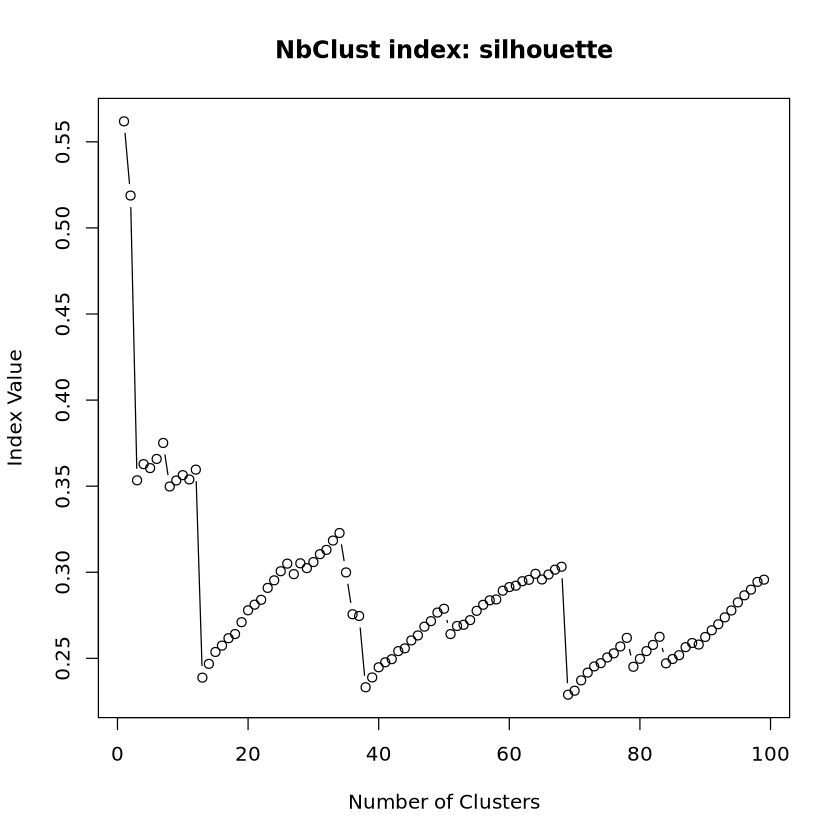


<U+0001F539> Processing index: gap 
<U+2705> Best number of clusters (gap) = 2
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_gap_GrpDist_All_0717_OH.csv 


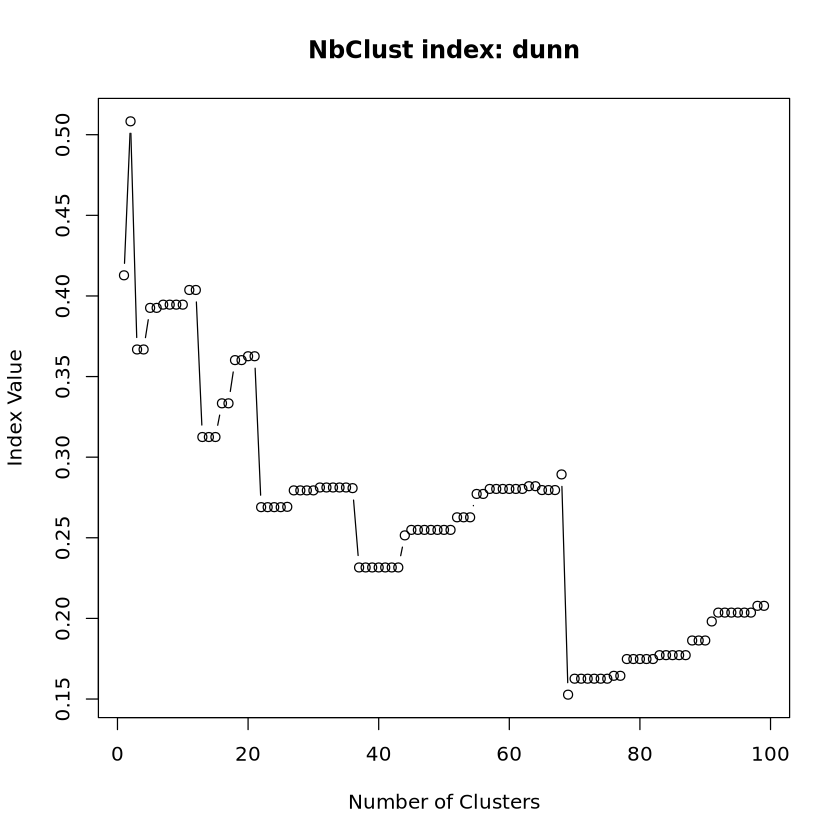


<U+0001F539> Processing index: ch 
<U+2705> Best number of clusters (ch) = 2
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_ch_GrpDist_All_0717_OH.csv 


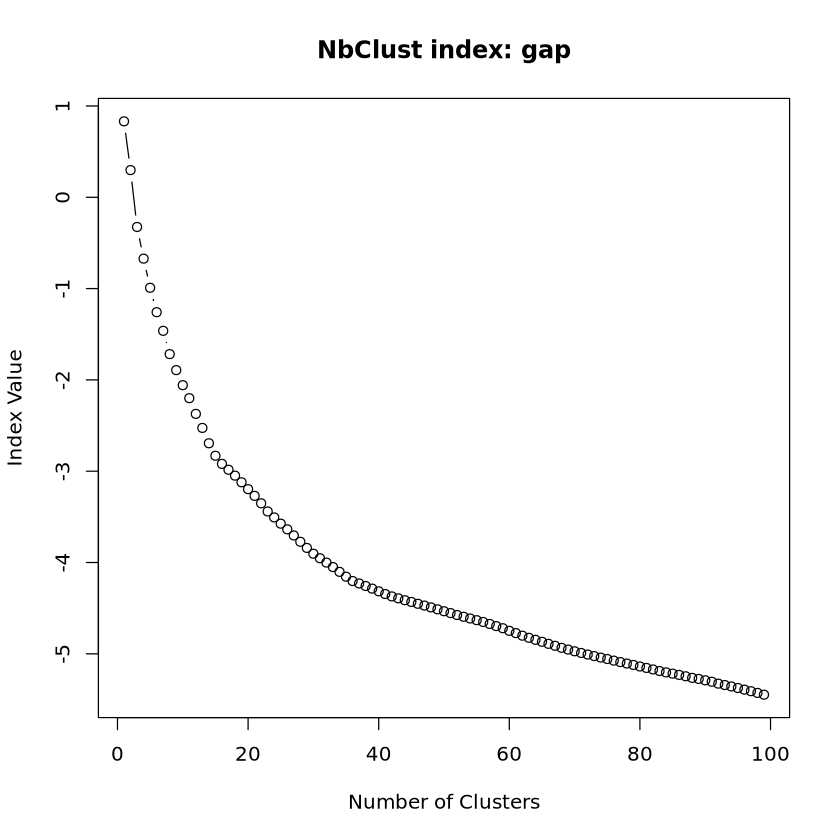


<U+0001F539> Processing index: db 
<U+2705> Best number of clusters (db) = 3
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_db_GrpDist_All_0717_OH.csv 


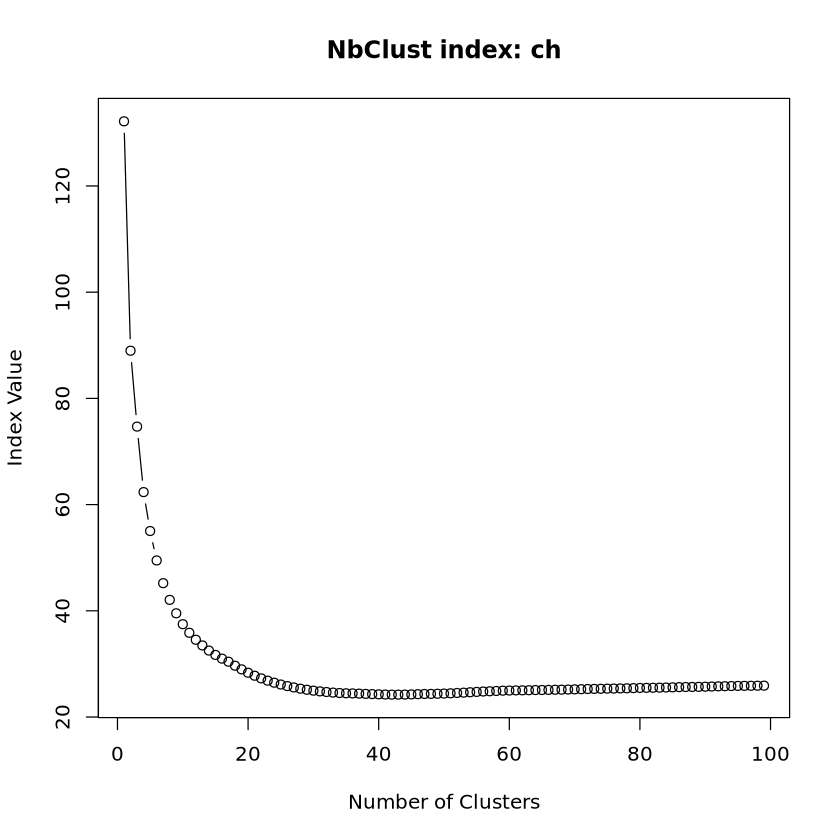


<U+0001F539> Processing index: ptbiserial 
<U+2705> Best number of clusters (ptbiserial) = 13
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_ptbiserial_GrpDist_All_0717_OH.csv 


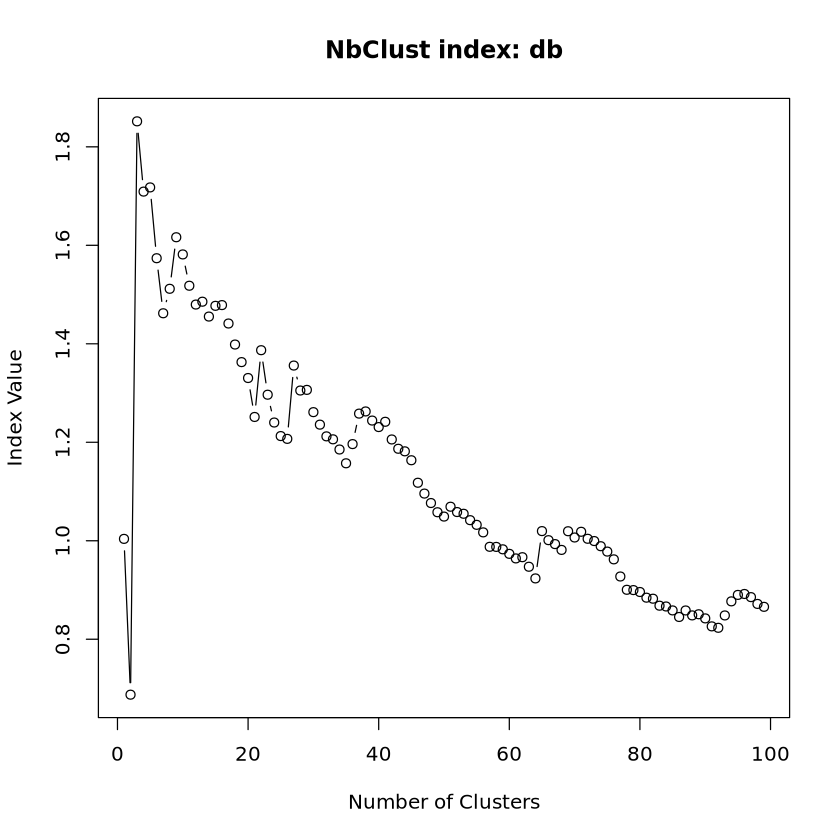

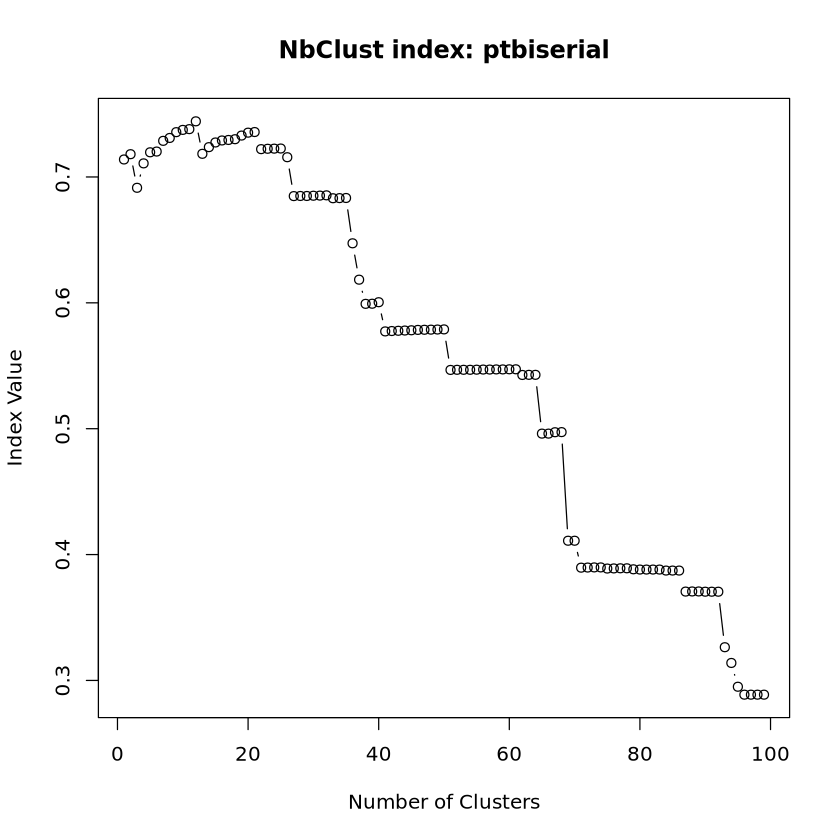

In [30]:
# --- パッケージの読み込み・インストール ---
if (!require(NbClust)) {
  install.packages("NbClust")
  library(NbClust)
}

# --- データの読み込み ---
ifname <- "DataMerge20211220oh_20250717_OH.csv"
readData <- read.delim(ifname, header = TRUE, sep = ",", row.names = 1, as.is = TRUE, strip.white = FALSE)

# --- 目的変数を除外 ---
target_vars <- c("PCEmax", "Jsc", "Voc", "FF")
expl_vars <- readData[, !(colnames(readData) %in% target_vars)]
removed_targets <- colnames(readData)[colnames(readData) %in% target_vars]

# --- 文字列を含む変数を除外（NA以外の文字列） ---
is_char_with_nonNA <- sapply(expl_vars, function(col) {
  any(grepl("[A-Za-z]", col) & col != "NA", na.rm = TRUE)
})
char_vars <- names(expl_vars)[is_char_with_nonNA]
expl_vars_clean <- expl_vars[, !colnames(expl_vars) %in% char_vars]
removed_char_vars <- char_vars

# --- 標準偏差が0の列を除去 ---
sd_nonzero <- apply(expl_vars_clean, 2, sd, na.rm = TRUE) != 0
numData <- expl_vars_clean[, sd_nonzero]
removed_sd_zero <- colnames(expl_vars_clean)[!sd_nonzero]

# --- スケーリング ---
numData_scaled <- scale(numData)

# --- 除去変数の記録と保存 ---
removal_log <- data.frame(
  Step = c(
    rep("Target variable", length(removed_targets)),
    rep("Non-numeric variable", length(removed_char_vars)),
    rep("Zero SD variable", length(removed_sd_zero))
  ),
  Removed_Variable = c(removed_targets, removed_char_vars, removed_sd_zero)
)
write.csv(removal_log, file = "RemovedVariablesSummary.csv", row.names = FALSE)

# --- 相関距離行列の作成 ---
corData <- cor(numData_scaled, use = "pairwise.complete.obs")
corData[is.na(corData)] <- 0
ddata <- dist(1 - abs(corData))  # 相関係数の絶対値で距離定義
ddata_matrix <- as.matrix(ddata)

# --- MDS（主座標分析） ---
Nvars <- ncol(numData)
kmax <- min(Nvars - 1, 100)
if (kmax < 2) stop("⚠️ 変数数が少なすぎてクラスタリングできません")

mdsdata <- cmdscale(ddata, k = kmax, eig = TRUE)

# --- 評価指標リスト（重いものは除く） ---
index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")

# --- クラスタリングと距離出力 ---
for (cindex in index_list) {
  cat("\n🔹 Processing index:", cindex, "\n")

  tryCatch({
    clustEst <- NbClust(
      data = mdsdata$points,
      diss = NULL,
      distance = "euclidean",
      min.nc = 2,
      max.nc = kmax,
      method = "ward.D2",
      index = cindex
    )

    # --- ベストクラスタ数と分類 ---
    best_nc <- clustEst$Best.nc[1]
    grpname <- as.factor(clustEst$Best.partition)
    cat(paste0("✅ Best number of clusters (", cindex, ") = ", best_nc, "\n"))

    # --- 各変数の平均距離を計算 ---
    avg_dist <- rowMeans(ddata_matrix)
    df_cluster_distance <- data.frame(
      Variable = names(grpname),
      Cluster = grpname,
      AvgDistance = avg_dist[names(grpname)]
    )

    # --- CSV出力 ---
    fn <- paste0("New_NbClust_", cindex, "_GrpDist_All_0717_OH.csv")
    write.csv(df_cluster_distance, file = fn, row.names = FALSE)

    cat("✅ 保存しました: ", fn, "\n")

    # --- スコアプロット ---
    plot(clustEst$All.index, type = "b",
         main = paste("NbClust index:", cindex),
         xlab = "Number of Clusters", ylab = "Index Value")

  }, error = function(e) {
    warning(paste("⚠️ Index", cindex, "failed:", e$message))
  })
}


Warning message in cor(numData_scaled, use = "pairwise.complete.obs"):
"the standard deviation is zero"



<U+0001F539> Processing index: silhouette 
<U+2705> Best number of clusters (silhouette) = 2
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_silhouette_GrpDist_All_0717_OH.csv 

<U+0001F539> Processing index: dunn 
<U+2705> Best number of clusters (dunn) = 3
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_dunn_GrpDist_All_0717_OH.csv 


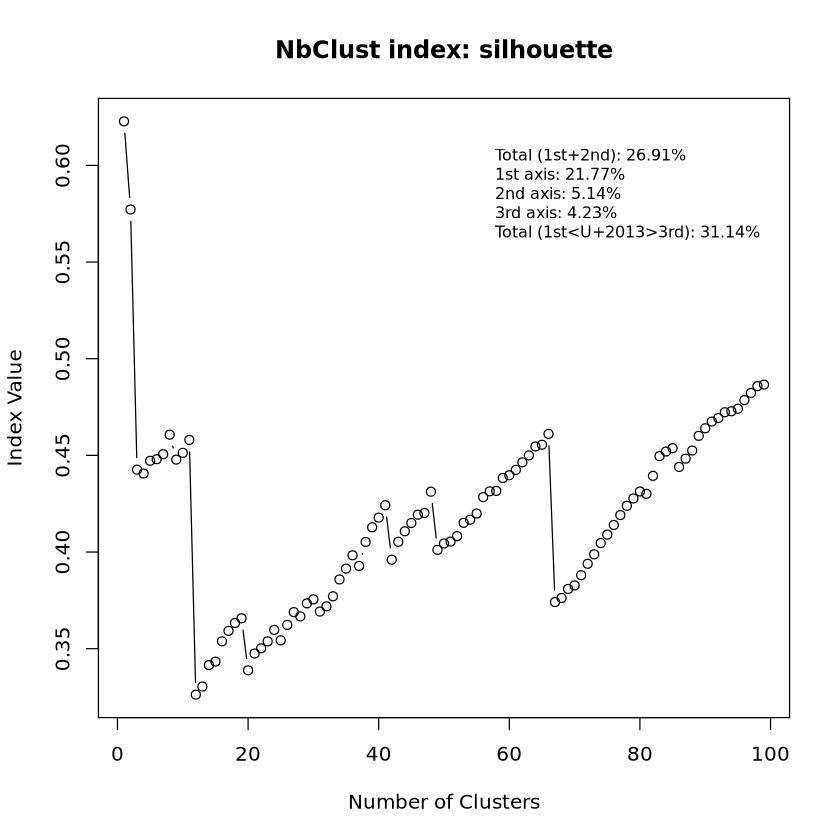


<U+0001F539> Processing index: gap 
<U+2705> Best number of clusters (gap) = 2
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_gap_GrpDist_All_0717_OH.csv 


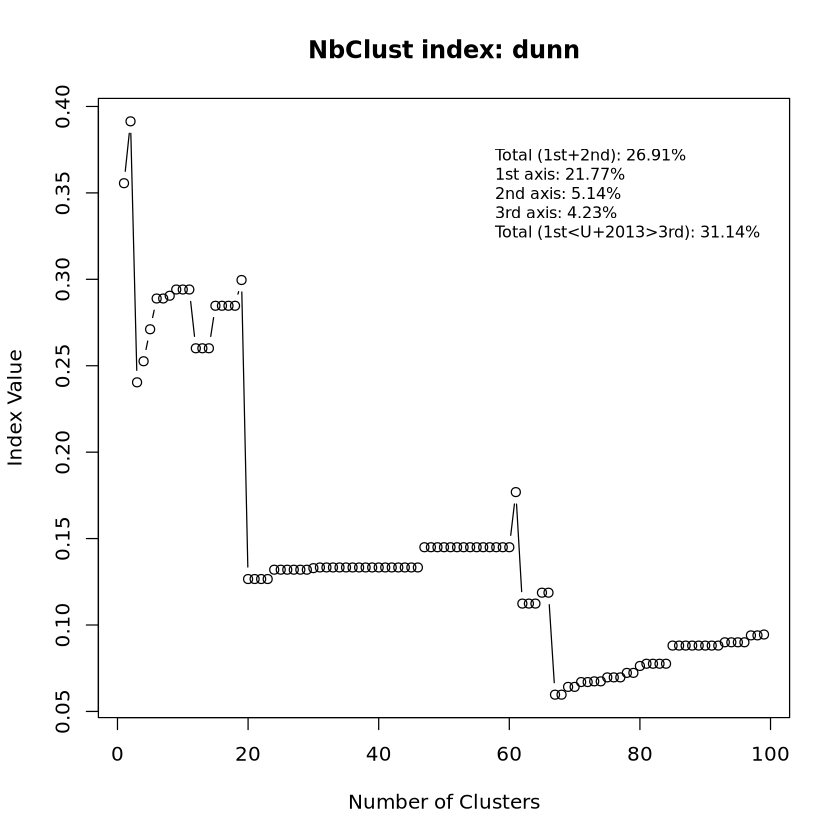


<U+0001F539> Processing index: ch 
<U+2705> Best number of clusters (ch) = 2
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_ch_GrpDist_All_0717_OH.csv 


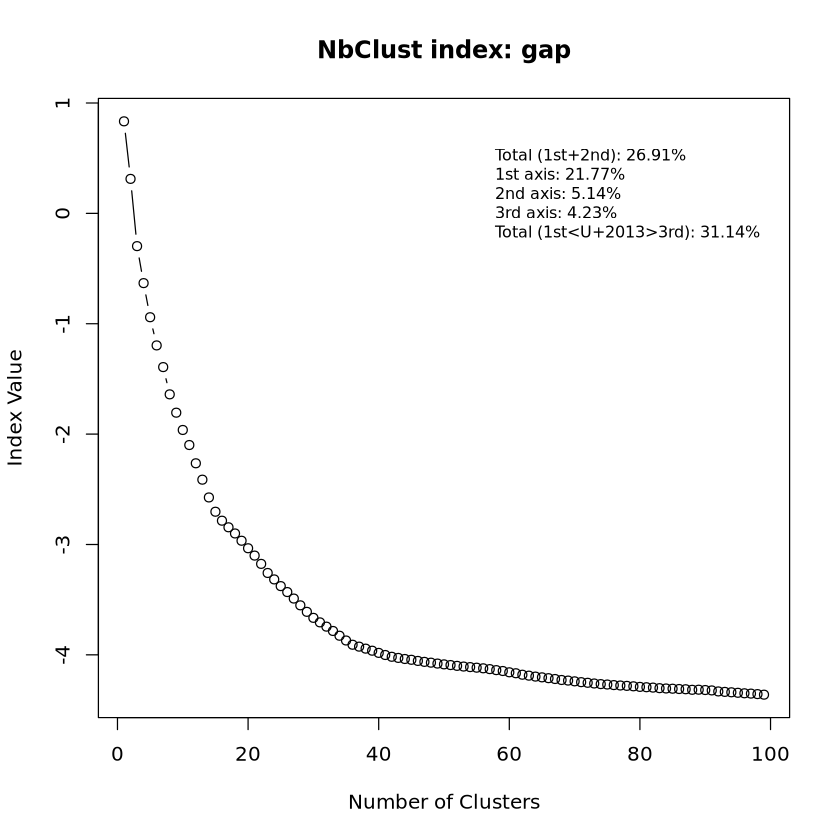


<U+0001F539> Processing index: db 
<U+2705> Best number of clusters (db) = 100
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_db_GrpDist_All_0717_OH.csv 


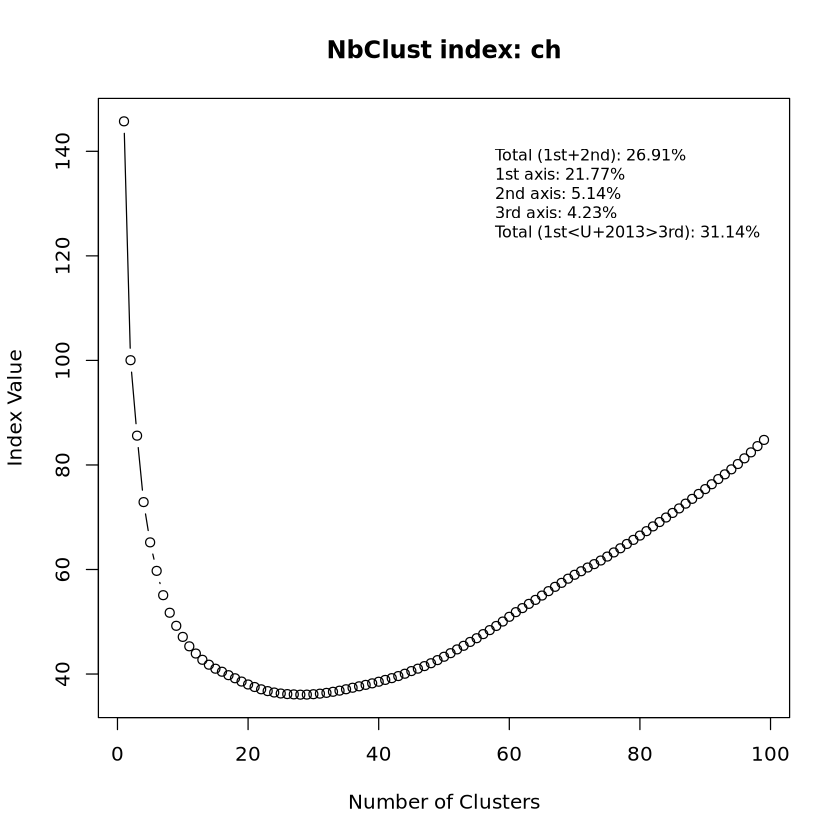


<U+0001F539> Processing index: ptbiserial 
<U+2705> Best number of clusters (ptbiserial) = 12
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_ptbiserial_GrpDist_All_0717_OH.csv 


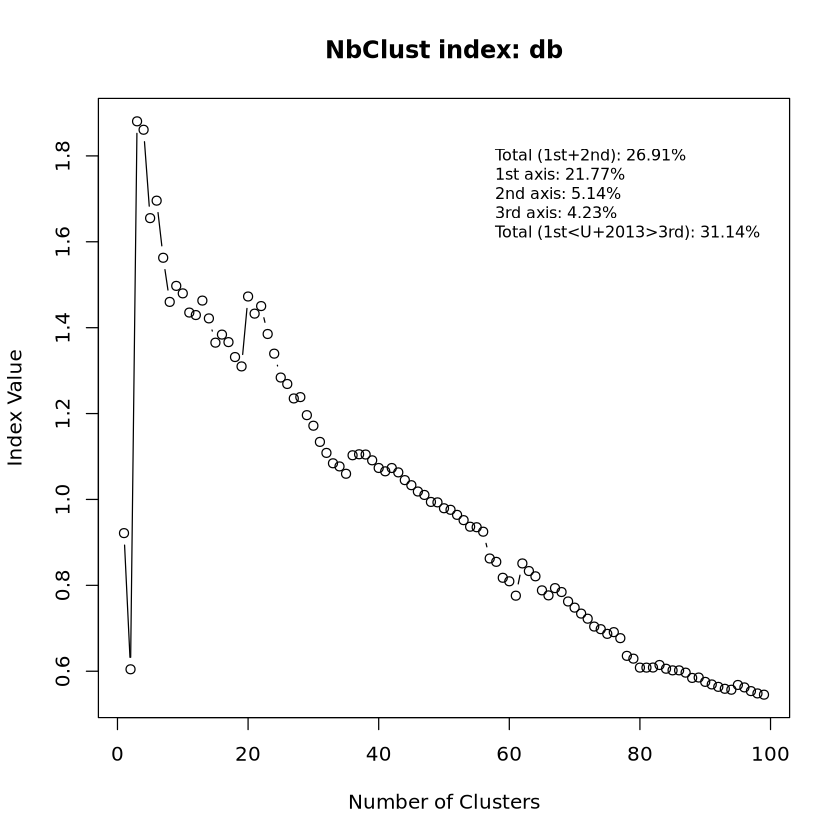

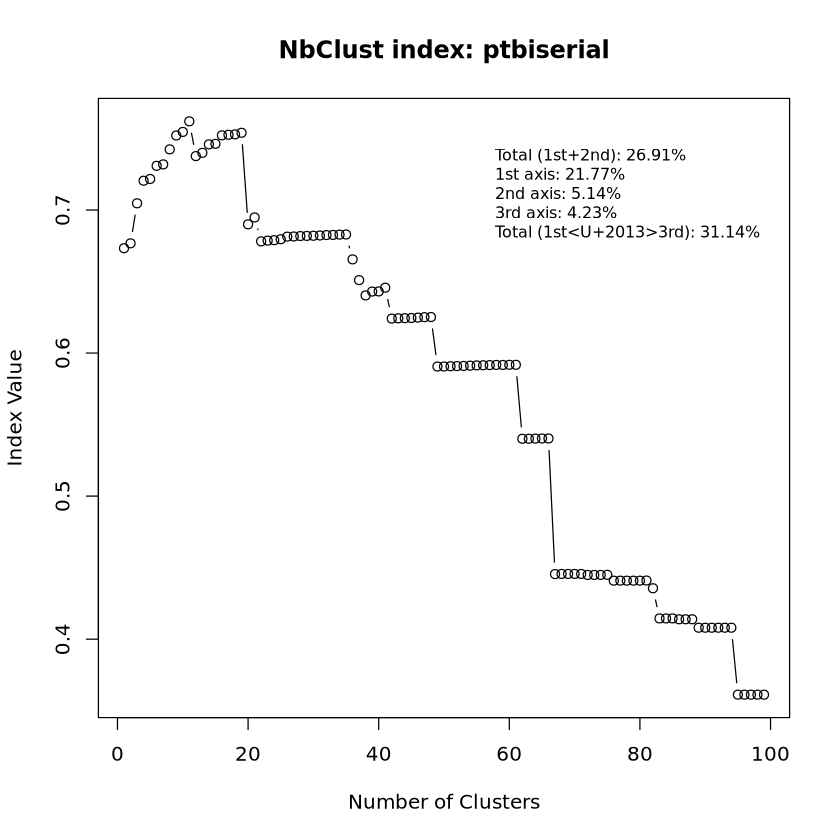

In [32]:
# --- パッケージの読み込み・インストール ---
if (!require(NbClust)) {
  install.packages("NbClust")
  library(NbClust)
}

# --- データの読み込み ---
ifname <- "DataMerge20211220oh_20250717_OH.csv"
readData <- read.delim(ifname, header = TRUE, sep = ",", row.names = 1, as.is = TRUE, strip.white = FALSE)

# --- 目的変数を除外 ---
target_vars <- c("PCEmax", "Jsc", "Voc", "FF")
expl_vars <- readData[, !(colnames(readData) %in% target_vars)]
removed_targets <- colnames(readData)[colnames(readData) %in% target_vars]

# --- 文字列を含む変数を除外（NA以外の文字列） ---
is_char_with_nonNA <- sapply(expl_vars, function(col) {
  any(grepl("[A-Za-z]", col) & col != "NA", na.rm = TRUE)
})
char_vars <- names(expl_vars)[is_char_with_nonNA]
expl_vars_clean <- expl_vars[, !colnames(expl_vars) %in% char_vars]
removed_char_vars <- char_vars

# --- 標準偏差が0の列を除去 ---
sd_nonzero <- apply(expl_vars_clean, 2, sd, na.rm = TRUE) != 0
numData <- expl_vars_clean[, sd_nonzero]
removed_sd_zero <- colnames(expl_vars_clean)[!sd_nonzero]

# --- スケーリング ---
numData_scaled <- scale(numData)

# --- 除去変数の記録と保存 ---
removal_log <- data.frame(
  Step = c(
    rep("Target variable", length(removed_targets)),
    rep("Non-numeric variable", length(removed_char_vars)),
    rep("Zero SD variable", length(removed_sd_zero))
  ),
  Removed_Variable = c(removed_targets, removed_char_vars, removed_sd_zero)
)
write.csv(removal_log, file = "RemovedVariablesSummary.csv", row.names = FALSE)

# --- 相関距離行列の作成 ---
corData <- cor(numData_scaled, use = "pairwise.complete.obs")
corData[is.na(corData)] <- 0
ddata <- dist(1 - abs(corData))  # 相関係数の絶対値で距離定義
ddata_matrix <- as.matrix(ddata)

# --- MDS（主座標分析） ---
Nvars <- ncol(numData)
kmax <- min(Nvars - 1, 50)
if (kmax < 2) stop("⚠️ 変数数が少なすぎてクラスタリングできません")

mdsdata <- cmdscale(ddata, k = kmax, eig = TRUE)

# --- 評価指標リスト（重いものは除く） ---
index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")

# --- クラスタリングと距離出力 ---
for (cindex in index_list) {
  cat("\n🔹 Processing index:", cindex, "\n")

  tryCatch({
    clustEst <- NbClust(
      data = mdsdata$points,
      diss = NULL,
      distance = "euclidean",
      min.nc = 2,
      max.nc = 100, #maximum # ofcluster 
      method = "ward.D2",
      index = cindex
    )

    # --- ベストクラスタ数と分類 ---
    best_nc <- clustEst$Best.nc[1]
    grpname <- as.factor(clustEst$Best.partition)
    cat(paste0("✅ Best number of clusters (", cindex, ") = ", best_nc, "\n"))

    # --- 各変数の平均距離を計算 ---
    avg_dist <- rowMeans(ddata_matrix)
    df_cluster_distance <- data.frame(
      Variable = names(grpname),
      Cluster = grpname,
      AvgDistance = avg_dist[names(grpname)],
      MDS1 = mdsdata$points[,1][names(grpname)],
      MDS2 = mdsdata$points[,2][names(grpname)],
      MDS3 = mdsdata$points[,3][names(grpname)]
    )

    # --- CSV出力 ---
    fn <- paste0("New_NbClust_", cindex, "_GrpDist_All_0717_OH.csv")
    write.csv(df_cluster_distance, file = fn, row.names = FALSE)
    cat("✅ 保存しました: ", fn, "\n")

    # --- スコアプロット ---
    plot(clustEst$All.index, type = "b",
         main = paste("NbClust index:", cindex),
         xlab = "Number of Clusters", ylab = "Index Value")

    # --- 固有値と寄与率の計算 ---
    eigvals <- mdsdata$eig
    eigvals <- eigvals[eigvals > 0]  # 負の固有値を除外
    eig_ratio <- eigvals / sum(eigvals)
    cum_ratio <- cumsum(eig_ratio)

    # --- 寄与率の数値（小数第2位まで） ---
    p1 <- round(eig_ratio[1] * 100, 2)
    p2 <- round(eig_ratio[2] * 100, 2)
    p3 <- round(eig_ratio[3] * 100, 2)
    p1_2 <- round(p1 + p2, 2)
    p1_3 <- round(p1 + p2 + p3, 2)

    # --- 寄与率の注釈をプロットに追加 ---
    contrib_text <- paste0("Total (1st+2nd): ", p1_2, "%\n",
                           "1st axis: ", p1, "%\n",
                           "2nd axis: ", p2, "%\n",
                           "3rd axis: ", p3, "%\n",
                           "Total (1st–3rd): ", p1_3, "%")
    legend("topright", legend = contrib_text, bty = "n", cex = 0.8)

  }, error = function(e) {
    warning(paste("⚠️ Index", cindex, "failed:", e$message))
  })
}


Warning message in cor(numData_scaled, use = "pairwise.complete.obs"):
"the standard deviation is zero"



<U+0001F539> Processing index: silhouette 
<U+2705> Best number of clusters (silhouette) = 2
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_silhouette_GrpDist_All_0717_OH.csv 

<U+0001F539> Processing index: dunn 
<U+2705> Best number of clusters (dunn) = 3
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_dunn_GrpDist_All_0717_OH.csv 


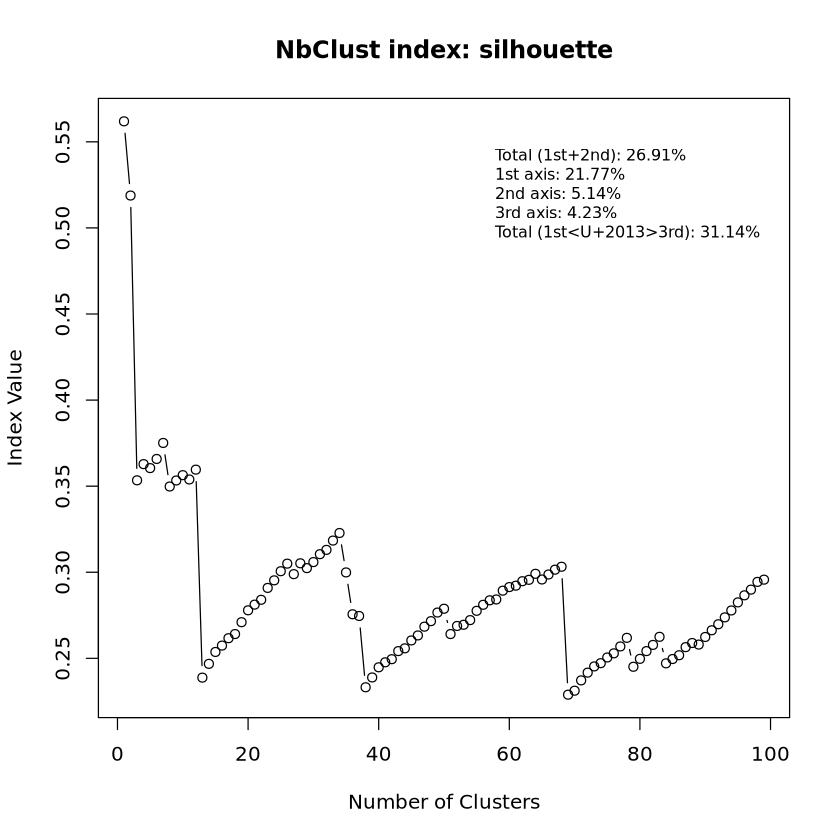


<U+0001F539> Processing index: gap 
<U+2705> Best number of clusters (gap) = 2
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_gap_GrpDist_All_0717_OH.csv 


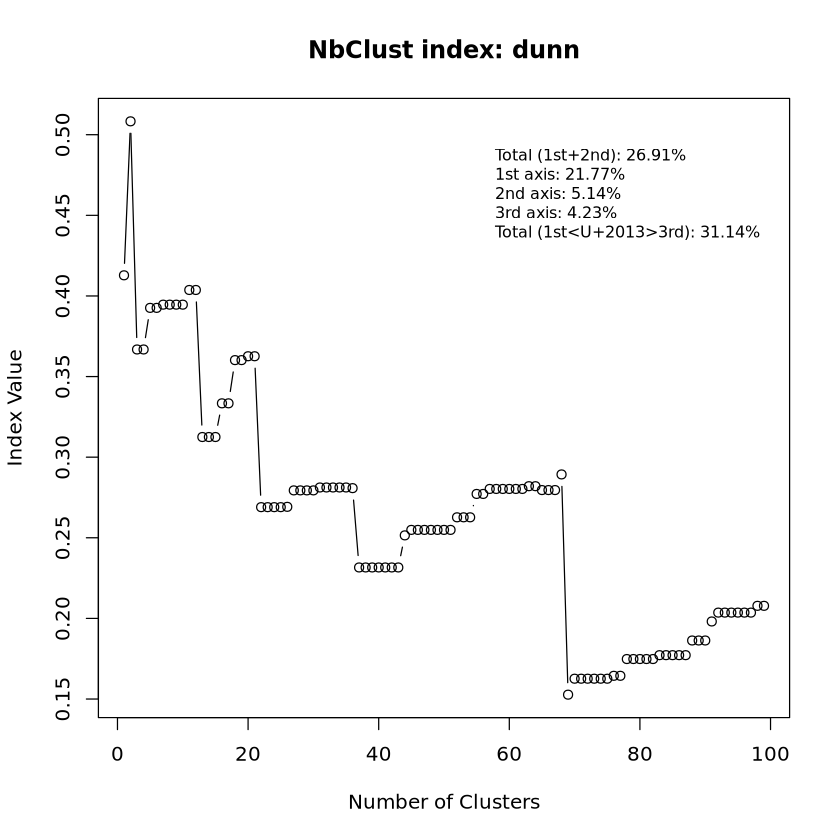


<U+0001F539> Processing index: ch 
<U+2705> Best number of clusters (ch) = 2
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_ch_GrpDist_All_0717_OH.csv 


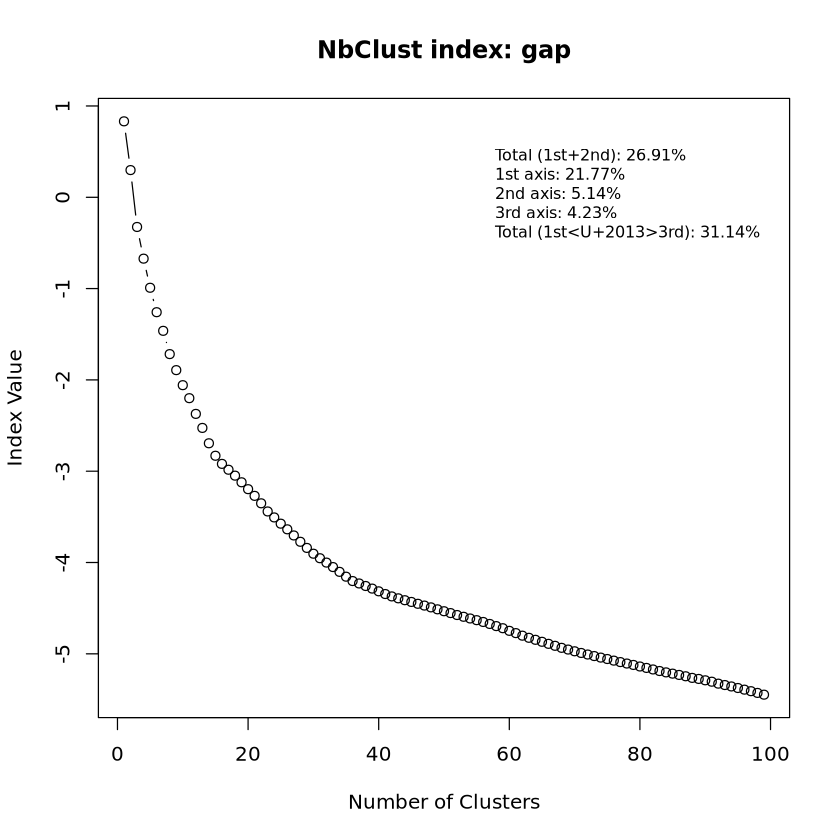


<U+0001F539> Processing index: db 
<U+2705> Best number of clusters (db) = 3
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_db_GrpDist_All_0717_OH.csv 


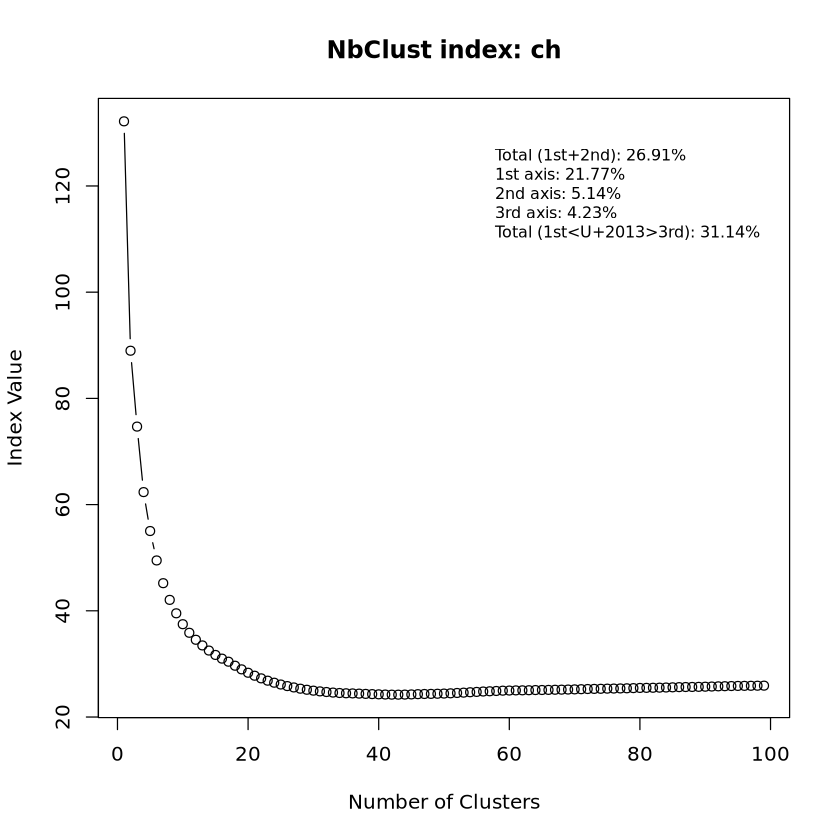


<U+0001F539> Processing index: ptbiserial 
<U+2705> Best number of clusters (ptbiserial) = 13
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_ptbiserial_GrpDist_All_0717_OH.csv 


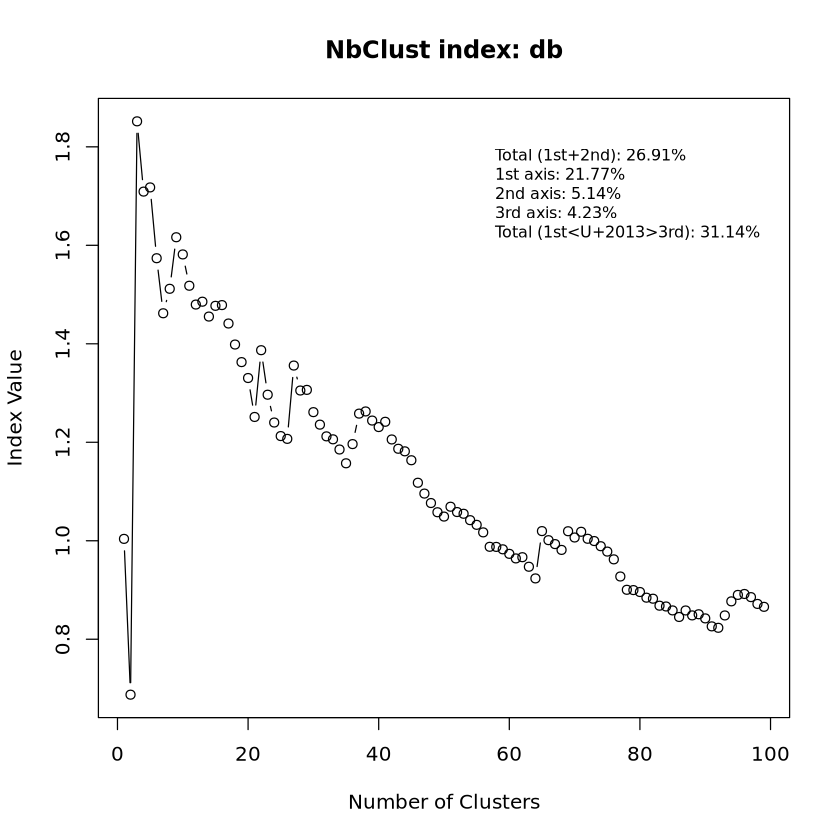

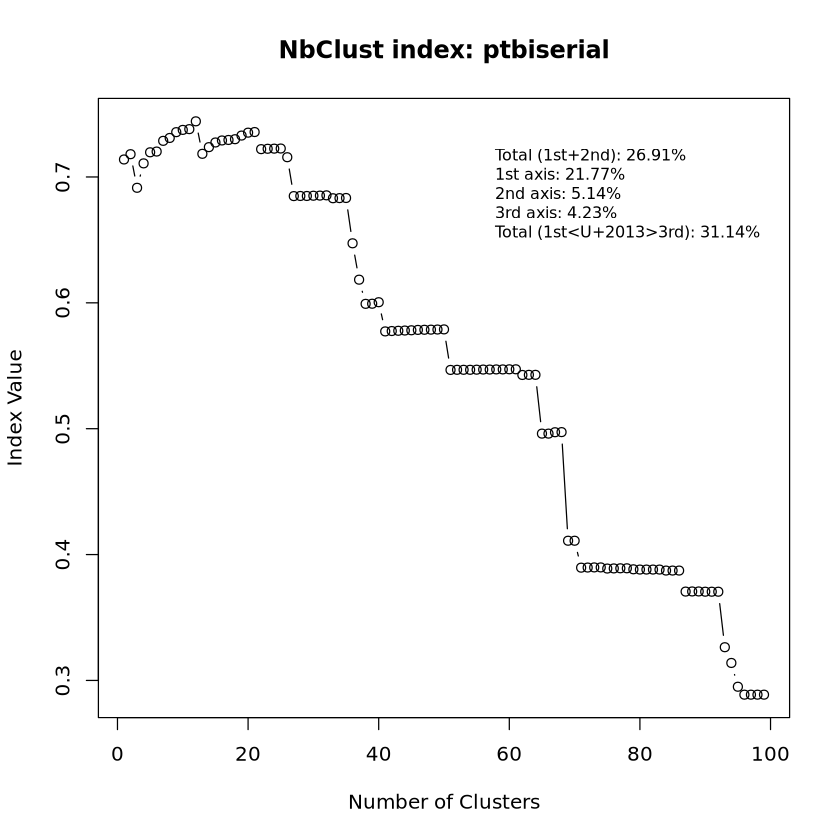

In [35]:
# --- パッケージの読み込み・インストール ---
if (!require(NbClust)) {
  install.packages("NbClust")
  library(NbClust)
}

# --- データの読み込み ---
ifname <- "DataMerge20211220oh_20250717_OH.csv"
readData <- read.delim(ifname, header = TRUE, sep = ",", row.names = 1, as.is = TRUE, strip.white = FALSE)

# --- 目的変数を除外 ---
target_vars <- c("PCEmax", "Jsc", "Voc", "FF")
expl_vars <- readData[, !(colnames(readData) %in% target_vars)]
removed_targets <- colnames(readData)[colnames(readData) %in% target_vars]

# --- 文字列を含む変数を除外（NA以外の文字列） ---
is_char_with_nonNA <- sapply(expl_vars, function(col) {
  any(grepl("[A-Za-z]", col) & col != "NA", na.rm = TRUE)
})
char_vars <- names(expl_vars)[is_char_with_nonNA]
expl_vars_clean <- expl_vars[, !colnames(expl_vars) %in% char_vars]
removed_char_vars <- char_vars

# --- 標準偏差が0の列を除去 ---
sd_nonzero <- apply(expl_vars_clean, 2, sd, na.rm = TRUE) != 0
numData <- expl_vars_clean[, sd_nonzero]
removed_sd_zero <- colnames(expl_vars_clean)[!sd_nonzero]

# --- スケーリング ---
numData_scaled <- scale(numData)

# --- 除去変数の記録と保存 ---
removal_log <- data.frame(
  Step = c(
    rep("Target variable", length(removed_targets)),
    rep("Non-numeric variable", length(removed_char_vars)),
    rep("Zero SD variable", length(removed_sd_zero))
  ),
  Removed_Variable = c(removed_targets, removed_char_vars, removed_sd_zero)
)
write.csv(removal_log, file = "RemovedVariablesSummary.csv", row.names = FALSE)

# --- 相関距離行列の作成 ---
corData <- cor(numData_scaled, use = "pairwise.complete.obs")
corData[is.na(corData)] <- 0
ddata <- dist(1 - abs(corData))  # 相関係数の絶対値で距離定義
ddata_matrix <- as.matrix(ddata)

# --- MDS（主座標分析） ---
Nvars <- ncol(numData)
kmax <- min(Nvars - 1, 100)
if (kmax < 2) stop("⚠️ 変数数が少なすぎてクラスタリングできません")

mdsdata <- cmdscale(ddata, k = kmax, eig = TRUE)

# --- 評価指標リスト（重いものは除く） ---
index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")

# --- クラスタリングと距離出力 ---
for (cindex in index_list) {
  cat("\n🔹 Processing index:", cindex, "\n")

  tryCatch({
    clustEst <- NbClust(
      data = mdsdata$points,
      diss = NULL,
      distance = "euclidean",
      min.nc = 2,
      max.nc = 100, #maximum # ofcluster 
      method = "ward.D2",
      index = cindex
    )

    # --- ベストクラスタ数と分類 ---
    best_nc <- clustEst$Best.nc[1]
    grpname <- as.factor(clustEst$Best.partition)
    cat(paste0("✅ Best number of clusters (", cindex, ") = ", best_nc, "\n"))

    # --- 各変数の平均距離を計算 ---
    avg_dist <- rowMeans(ddata_matrix)
    df_cluster_distance <- data.frame(
      Variable = names(grpname),
      Cluster = grpname,
      AvgDistance = avg_dist[names(grpname)],
      MDS1 = mdsdata$points[,1][names(grpname)],
      MDS2 = mdsdata$points[,2][names(grpname)],
      MDS3 = mdsdata$points[,3][names(grpname)]
    )

    # --- CSV出力 ---
    fn <- paste0("New_NbClust_", cindex, "_GrpDist_All_0717_OH.csv")
    write.csv(df_cluster_distance, file = fn, row.names = FALSE)
    cat("✅ 保存しました: ", fn, "\n")

    # --- スコアプロット ---
    plot(clustEst$All.index, type = "b",
         main = paste("NbClust index:", cindex),
         xlab = "Number of Clusters", ylab = "Index Value")

    # --- 固有値と寄与率の計算 ---
    eigvals <- mdsdata$eig
    eigvals <- eigvals[eigvals > 0]  # 負の固有値を除外
    eig_ratio <- eigvals / sum(eigvals)
    cum_ratio <- cumsum(eig_ratio)

    # --- 寄与率の数値（小数第2位まで） ---
    p1 <- round(eig_ratio[1] * 100, 2)
    p2 <- round(eig_ratio[2] * 100, 2)
    p3 <- round(eig_ratio[3] * 100, 2)
    p1_2 <- round(p1 + p2, 2)
    p1_3 <- round(p1 + p2 + p3, 2)

    # --- 寄与率の注釈をプロットに追加 ---
    contrib_text <- paste0("Total (1st+2nd): ", p1_2, "%\n",
                           "1st axis: ", p1, "%\n",
                           "2nd axis: ", p2, "%\n",
                           "3rd axis: ", p3, "%\n",
                           "Total (1st–3rd): ", p1_3, "%")
    legend("topright", legend = contrib_text, bty = "n", cex = 0.8)

  }, error = function(e) {
    warning(paste("⚠️ Index", cindex, "failed:", e$message))
  })
}


In [39]:
# 固有値ベクトルを取得（正の値のみ使用）
eig_values <- mdsdata$eig
eig_positive <- eig_values[eig_values > 0]

# 寄与率と累積寄与率を計算
eig_ratio <- eig_positive / sum(eig_positive)
cum_ratio <- cumsum(eig_ratio)

# 累積寄与率が80%を超える最小の軸数を取得
dim_80 <- which(cum_ratio >= 0.8)[1]

# 小数第2位までの累積寄与率も取得
cum_80_ratio <- round(cum_ratio[dim_80] * 100, 2)

# 出力
cat("✅ 累積寄与率が80%を超えるのに必要な軸数:", dim_80, "軸\n")
cat("📈 累積寄与率:", cum_80_ratio, "%\n")

n_axes <- ncol(mdsdata$points)
cat("MDSの軸の数:", n_axes, "軸\n")


<U+2705> <U+7D2F><U+7A4D><U+5BC4><U+4E0E><U+7387><U+304C>80%<U+3092><U+8D85><U+3048><U+308B><U+306E><U+306B><U+5FC5><U+8981><U+306A><U+8EF8><U+6570>: 157 <U+8EF8>
<U+0001F4C8> <U+7D2F><U+7A4D><U+5BC4><U+4E0E><U+7387>: 80.08 %
MDS<U+306E><U+8EF8><U+306E><U+6570>: 100 <U+8EF8>


In [43]:
# 固有値ベクトルを取得（正の値のみ使用）
eig_values <- mdsdata$eig
eig_positive <- eig_values[eig_values > 0]

# 寄与率と累積寄与率を計算
eig_ratio <- eig_positive / sum(eig_positive)
cum_ratio <- cumsum(eig_ratio)

# 小数第2位までに整形
eig_ratio_rounded <- round(eig_ratio[1:3] * 100, 2)
cum_ratio_rounded <- round(cum_ratio[1:3] * 100, 2)

# 結果を表示
cat("📊 第1軸の寄与率: ", eig_ratio_rounded[1], "%\n")
cat("📊 第2軸の寄与率: ", eig_ratio_rounded[2], "%\n")
cat("📊 第3軸の寄与率: ", eig_ratio_rounded[3], "%\n")
cat("📈 第3軸までの累積寄与率: ", cum_ratio_rounded[3], "%\n")


<U+0001F4CA> <U+7B2C>1<U+8EF8><U+306E><U+5BC4><U+4E0E><U+7387>:  21.77 %
<U+0001F4CA> <U+7B2C>2<U+8EF8><U+306E><U+5BC4><U+4E0E><U+7387>:  5.14 %
<U+0001F4CA> <U+7B2C>3<U+8EF8><U+306E><U+5BC4><U+4E0E><U+7387>:  4.23 %
<U+0001F4C8> <U+7B2C>3<U+8EF8><U+307E><U+3067><U+306E><U+7D2F><U+7A4D><U+5BC4><U+4E0E><U+7387>:  31.15 %


Warning message in cor(numData_scaled, use = "pairwise.complete.obs"):
"the standard deviation is zero"



<U+0001F539> Processing index: silhouette 
<U+2705> Best number of clusters (silhouette) = 2
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_silhouette_GrpDist_All_0717_OH.csv 

<U+0001F539> Processing index: dunn 
<U+2705> Best number of clusters (dunn) = 3
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_dunn_GrpDist_All_0717_OH.csv 


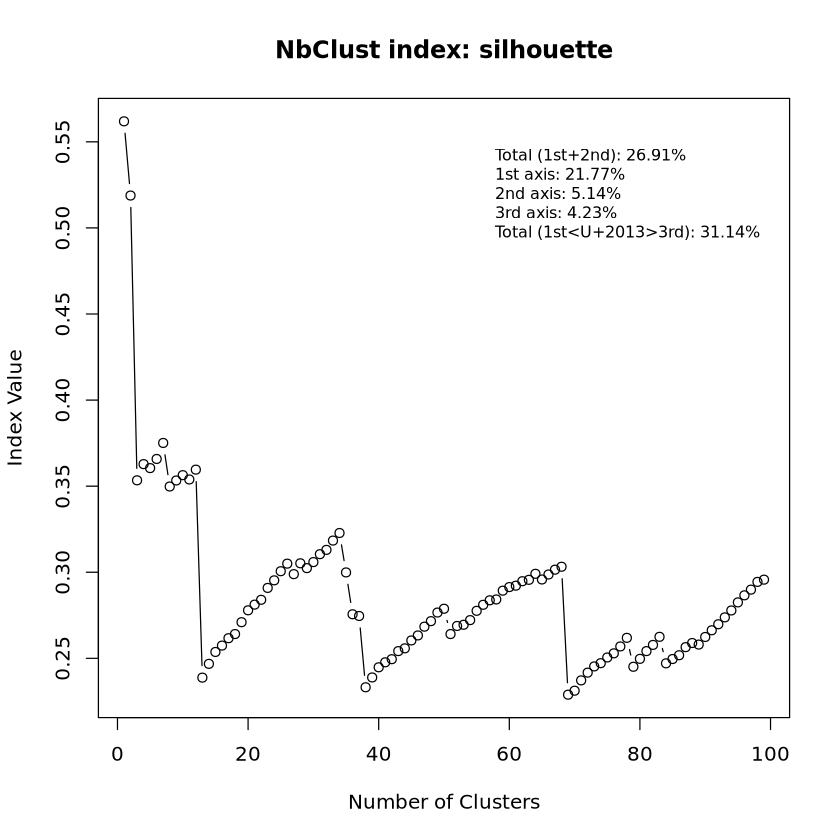


<U+0001F539> Processing index: gap 
<U+2705> Best number of clusters (gap) = 2
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_gap_GrpDist_All_0717_OH.csv 


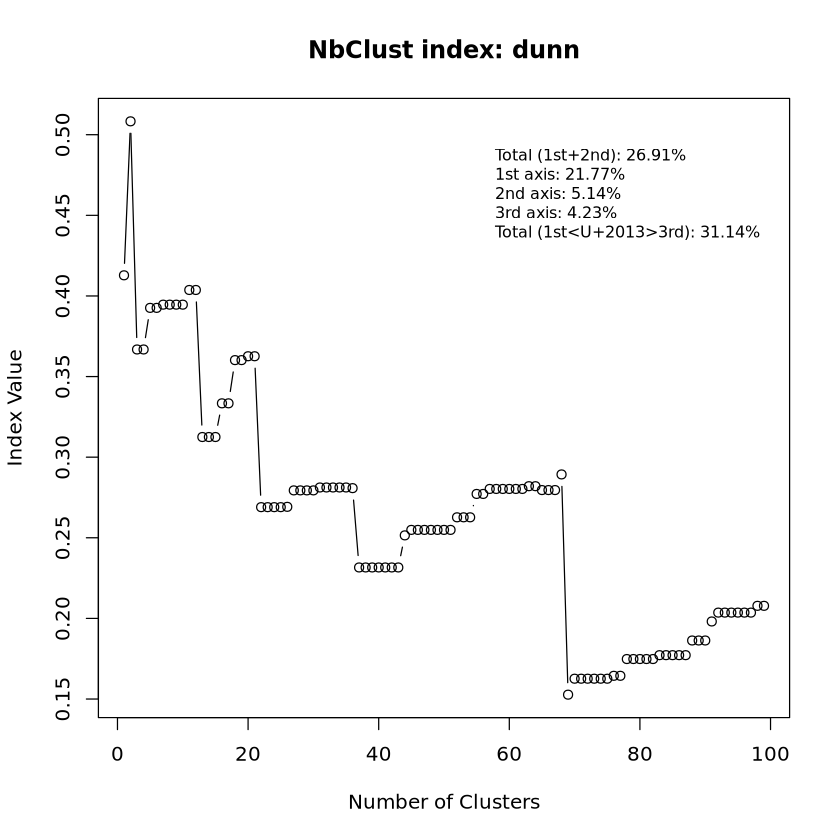


<U+0001F539> Processing index: ch 
<U+2705> Best number of clusters (ch) = 2
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_ch_GrpDist_All_0717_OH.csv 


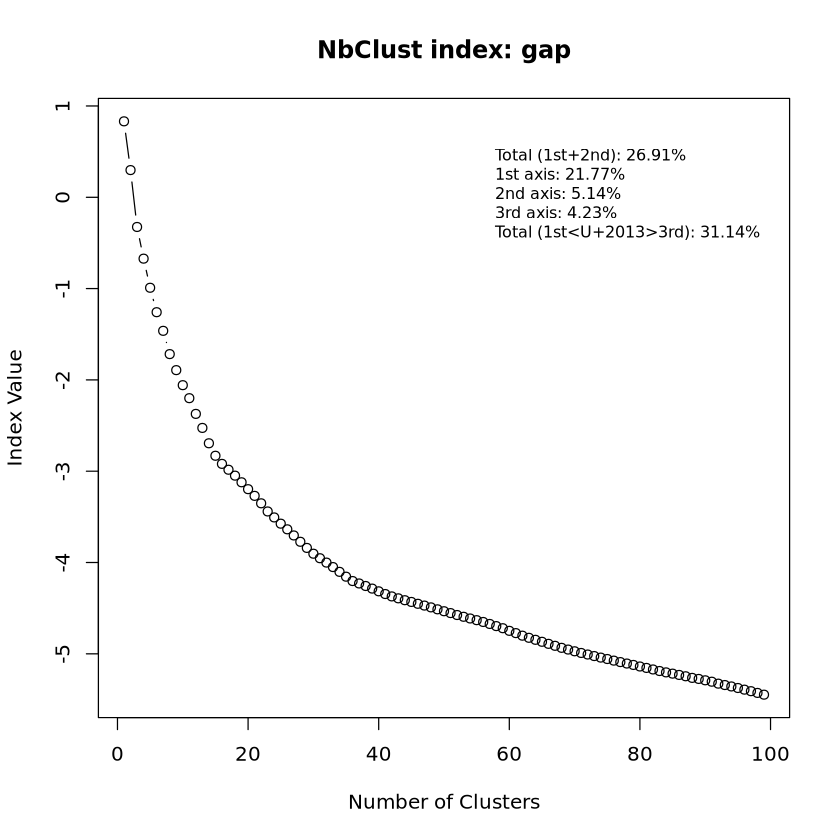


<U+0001F539> Processing index: db 
<U+2705> Best number of clusters (db) = 3
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_db_GrpDist_All_0717_OH.csv 


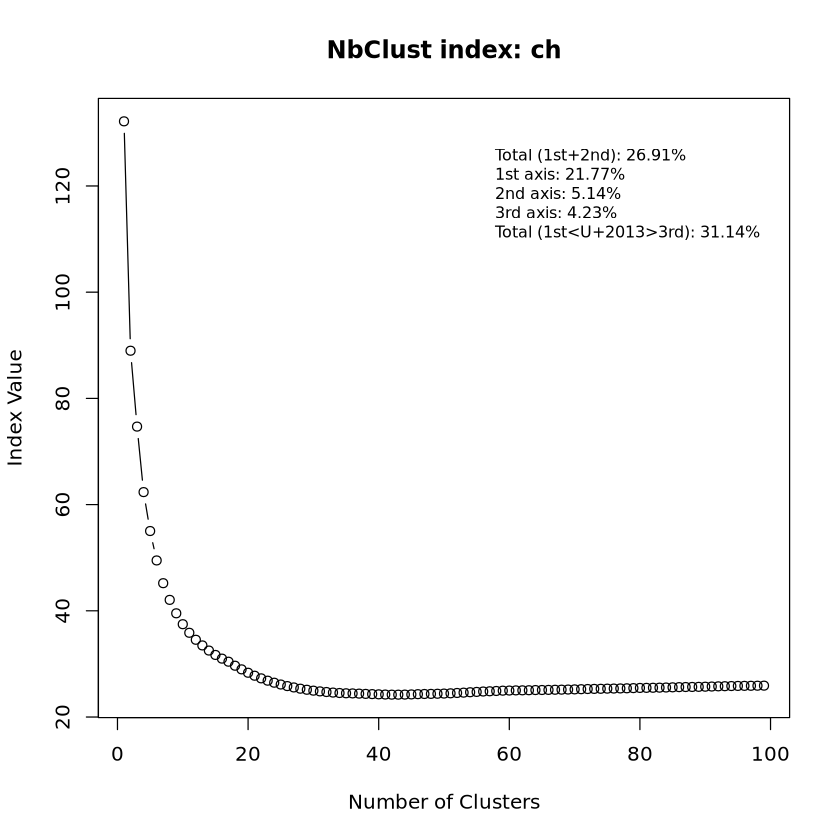


<U+0001F539> Processing index: ptbiserial 
<U+2705> Best number of clusters (ptbiserial) = 13
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_ptbiserial_GrpDist_All_0717_OH.csv 


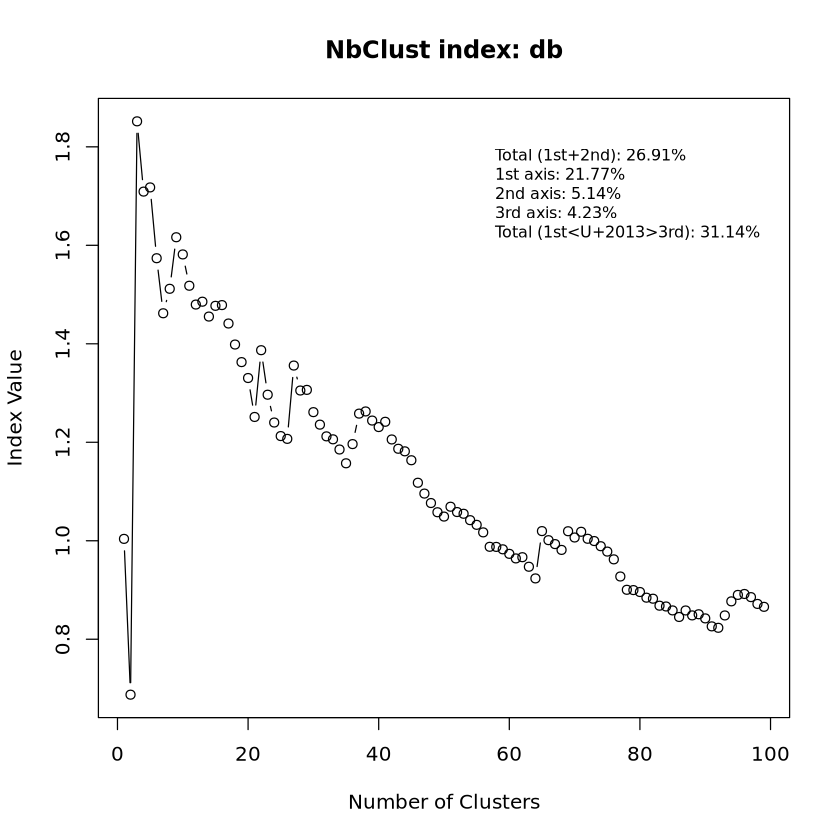

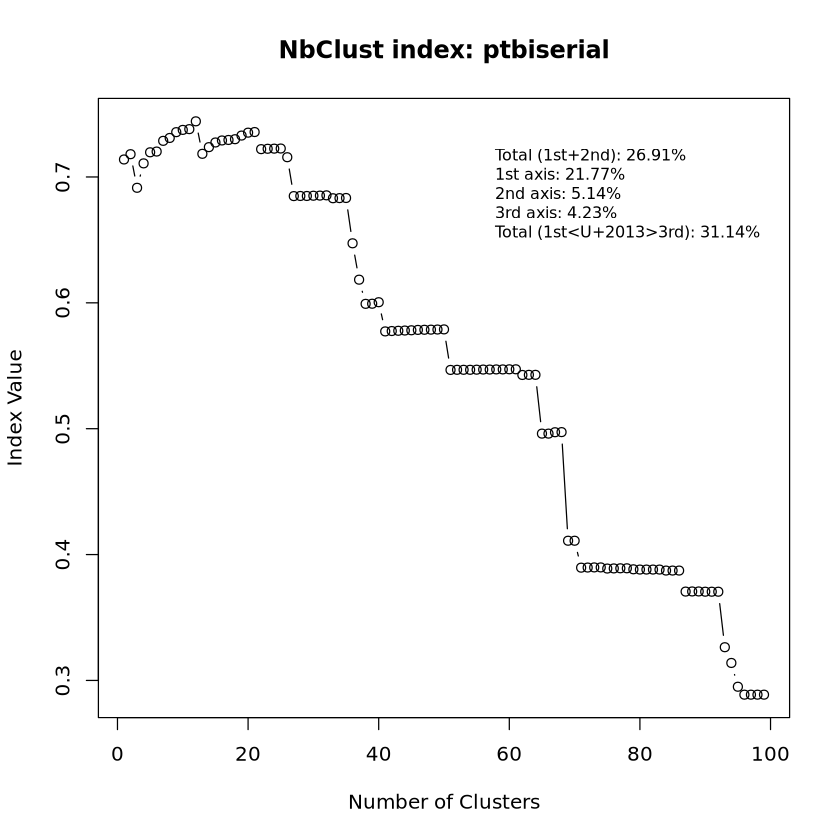

In [47]:
# --- パッケージの読み込み・インストール ---
if (!require(NbClust)) {
  install.packages("NbClust")
  library(NbClust)
}

# --- データの読み込み ---
ifname <- "DataMerge20211220oh_20250717_OH.csv"
readData <- read.delim(ifname, header = TRUE, sep = ",", row.names = 1, as.is = TRUE, strip.white = FALSE)

# --- 目的変数を除外 ---
target_vars <- c("PCEmax", "Jsc", "Voc", "FF")
expl_vars <- readData[, !(colnames(readData) %in% target_vars)]
removed_targets <- colnames(readData)[colnames(readData) %in% target_vars]

# --- 文字列を含む変数を除外（NA以外の文字列） ---
is_char_with_nonNA <- sapply(expl_vars, function(col) {
  any(grepl("[A-Za-z]", col) & col != "NA", na.rm = TRUE)
})
char_vars <- names(expl_vars)[is_char_with_nonNA]
expl_vars_clean <- expl_vars[, !colnames(expl_vars) %in% char_vars]
removed_char_vars <- char_vars

# --- 標準偏差が0の列を除去 ---
sd_nonzero <- apply(expl_vars_clean, 2, sd, na.rm = TRUE) != 0
numData <- expl_vars_clean[, sd_nonzero]
removed_sd_zero <- colnames(expl_vars_clean)[!sd_nonzero]

# --- スケーリング ---
numData_scaled <- scale(numData)

# --- 除去変数の記録と保存 ---
removal_log <- data.frame(
  Step = c(
    rep("Target variable", length(removed_targets)),
    rep("Non-numeric variable", length(removed_char_vars)),
    rep("Zero SD variable", length(removed_sd_zero))
  ),
  Removed_Variable = c(removed_targets, removed_char_vars, removed_sd_zero)
)
write.csv(removal_log, file = "RemovedVariablesSummary.csv", row.names = FALSE)

# --- 相関距離行列の作成 ---
corData <- cor(numData_scaled, use = "pairwise.complete.obs")
corData[is.na(corData)] <- 0
ddata <- dist(1 - abs(corData))  # 相関係数の絶対値で距離定義
ddata_matrix <- as.matrix(ddata)

# --- MDS（主座標分析） ---
Nvars <- ncol(numData)
kmax <- min(Nvars - 1, 100)
if (kmax < 2) stop("⚠️ 変数数が少なすぎてクラスタリングできません")

mdsdata <- cmdscale(ddata, k = kmax, eig = TRUE)

# --- 評価指標リスト（重いものは除く） ---
index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")

# --- クラスタリングと距離出力 ---
for (cindex in index_list) {
  cat("\n🔹 Processing index:", cindex, "\n")

  tryCatch({
    clustEst <- NbClust(
      data = mdsdata$points,
      diss = NULL,
      distance = "euclidean",
      min.nc = 2,
      max.nc = 100, #maximum # ofcluster 
      method = "ward.D2",
      index = cindex
    )

    # --- ベストクラスタ数と分類 ---
    best_nc <- clustEst$Best.nc[1]
    grpname <- as.factor(clustEst$Best.partition)
    cat(paste0("✅ Best number of clusters (", cindex, ") = ", best_nc, "\n"))

    # --- 各変数の平均距離を計算 ---
    avg_dist <- rowMeans(ddata_matrix)
    df_cluster_distance <- data.frame(
      Variable = names(grpname),
      Cluster = grpname,
      AvgDistance = avg_dist[names(grpname)],
      MDS1 = mdsdata$points[,1][names(grpname)],
      MDS2 = mdsdata$points[,2][names(grpname)],
      MDS3 = mdsdata$points[,3][names(grpname)]
    )

    # --- CSV出力 ---
    fn <- paste0("New_NbClust_", cindex, "_GrpDist_All_0717_OH.csv")
    write.csv(df_cluster_distance, file = fn, row.names = FALSE)
    cat("✅ 保存しました: ", fn, "\n")

    # --- スコアプロット ---
    plot(clustEst$All.index, type = "b",
         main = paste("NbClust index:", cindex),
         xlab = "Number of Clusters", ylab = "Index Value")

    # --- 固有値と寄与率の計算 ---
    eigvals <- mdsdata$eig
    eigvals <- eigvals[eigvals > 0]  # 負の固有値を除外
    eig_ratio <- eigvals / sum(eigvals)
    cum_ratio <- cumsum(eig_ratio)

    # --- 寄与率の数値（小数第2位まで） ---
    p1 <- round(eig_ratio[1] * 100, 2)
    p2 <- round(eig_ratio[2] * 100, 2)
    p3 <- round(eig_ratio[3] * 100, 2)
    p1_2 <- round(p1 + p2, 2)
    p1_3 <- round(p1 + p2 + p3, 2)

    # --- 寄与率の注釈をプロットに追加 ---
    contrib_text <- paste0("Total (1st+2nd): ", p1_2, "%\n",
                           "1st axis: ", p1, "%\n",
                           "2nd axis: ", p2, "%\n",
                           "3rd axis: ", p3, "%\n",
                           "Total (1st–3rd): ", p1_3, "%")
    legend("topright", legend = contrib_text, bty = "n", cex = 0.8)

  }, error = function(e) {
    warning(paste("⚠️ Index", cindex, "failed:", e$message))
  })
}


Warning message in cor(numData_scaled, use = "pairwise.complete.obs"):
"the standard deviation is zero"


<U+2705> <U+7D2F><U+7A4D><U+5BC4><U+4E0E><U+7387><U+304C>80%<U+3092><U+8D85><U+3048><U+308B><U+306E><U+306B><U+5FC5><U+8981><U+306A><U+8EF8><U+6570>: 157 <U+8EF8>
<U+0001F4C8> <U+7D2F><U+7A4D><U+5BC4><U+4E0E><U+7387>: 80.08 %
<U+0001F4CA> MDS<U+306E><U+8EF8><U+306E><U+6570>: 100 <U+8EF8>

<U+0001F539> Processing index: silhouette 
<U+2705> Best number of clusters (silhouette) = 2
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_silhouette_GrpDist_All_0717_OH_0.8.csv 


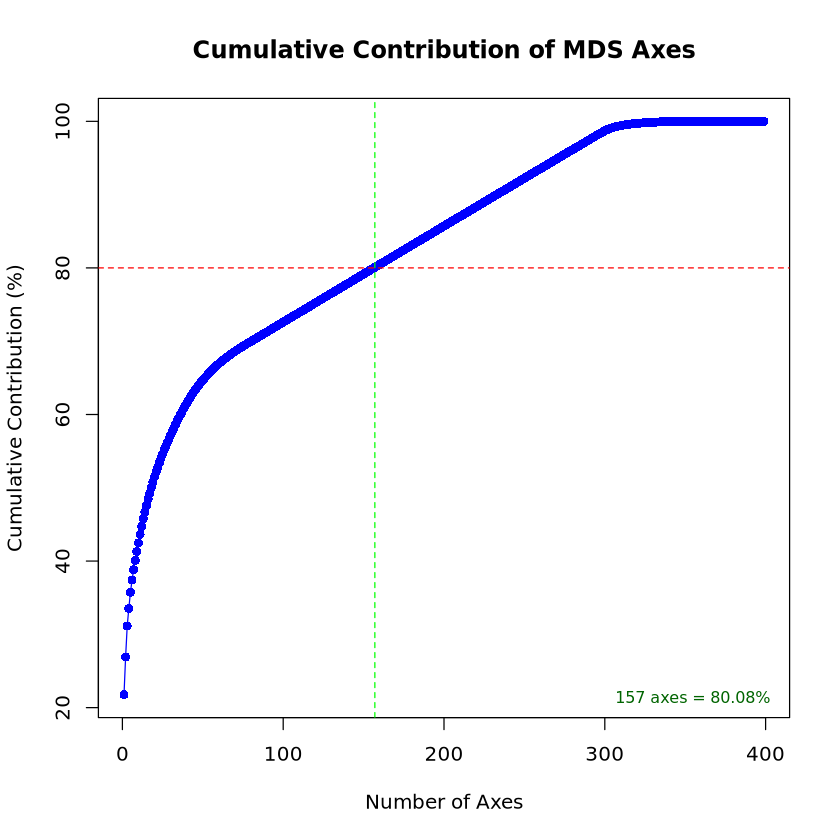


<U+0001F539> Processing index: dunn 
<U+2705> Best number of clusters (dunn) = 3
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_dunn_GrpDist_All_0717_OH_0.8.csv 


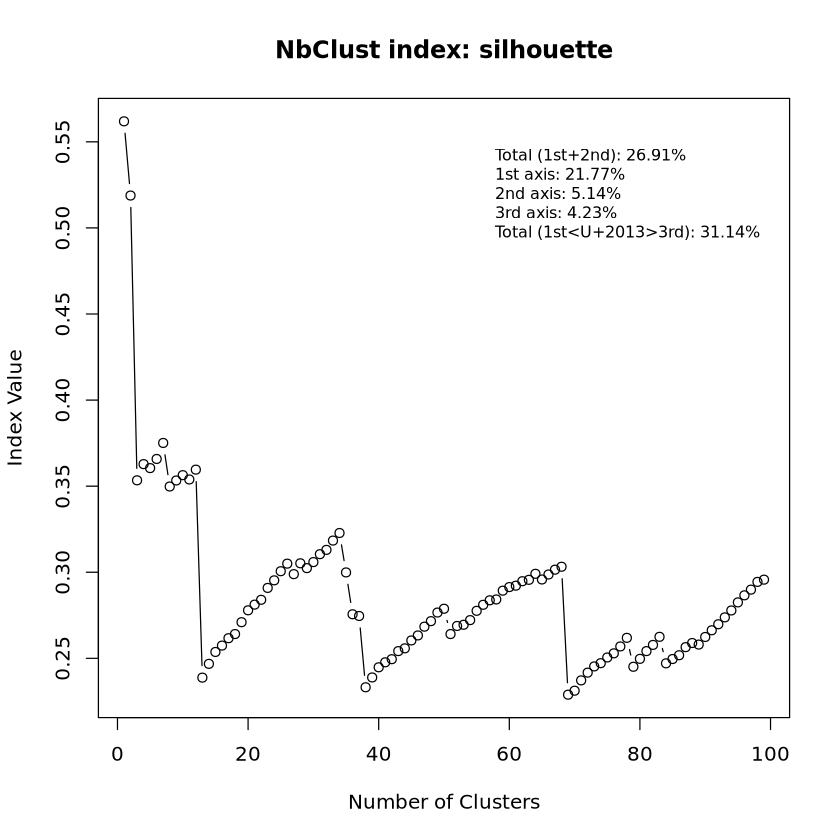


<U+0001F539> Processing index: gap 
<U+2705> Best number of clusters (gap) = 2
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_gap_GrpDist_All_0717_OH_0.8.csv 


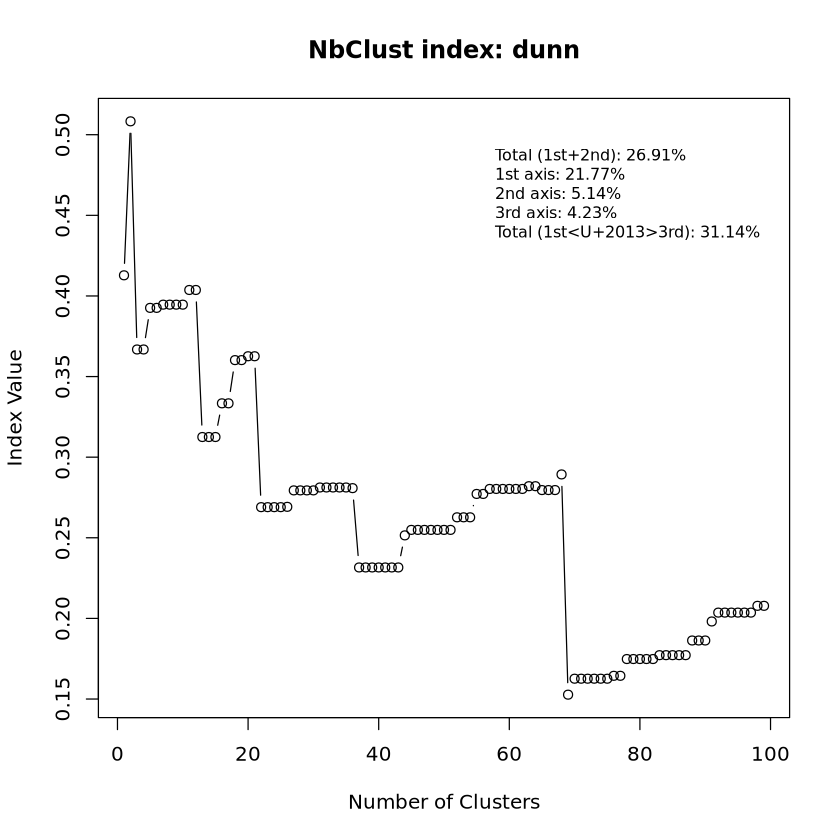


<U+0001F539> Processing index: ch 
<U+2705> Best number of clusters (ch) = 2
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_ch_GrpDist_All_0717_OH_0.8.csv 


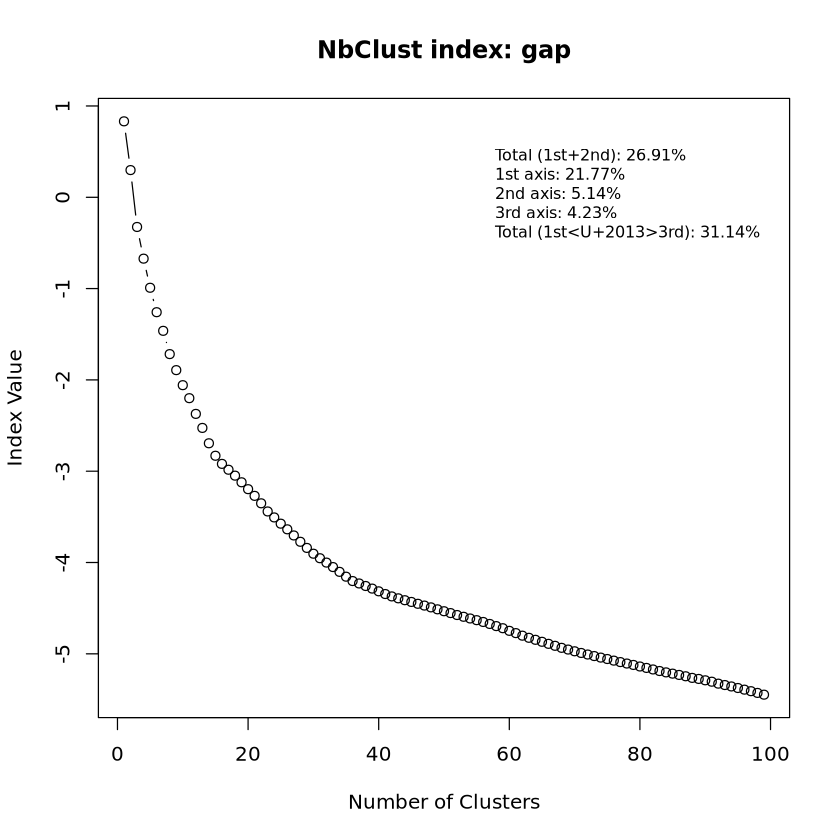


<U+0001F539> Processing index: db 
<U+2705> Best number of clusters (db) = 3
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_db_GrpDist_All_0717_OH_0.8.csv 


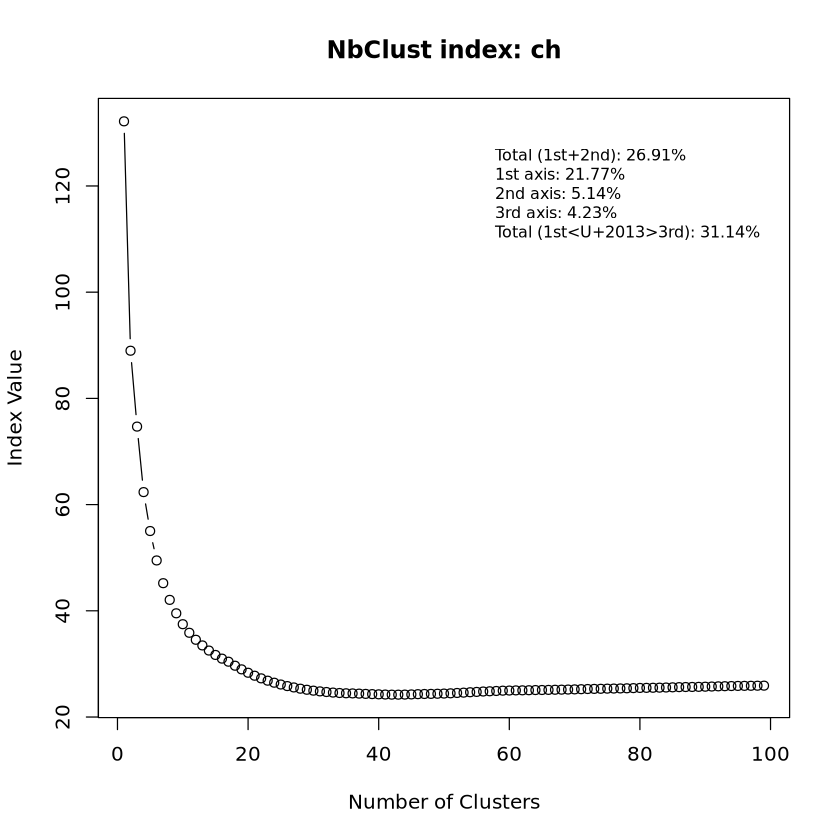


<U+0001F539> Processing index: ptbiserial 
<U+2705> Best number of clusters (ptbiserial) = 13
<U+2705> <U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:  New_NbClust_ptbiserial_GrpDist_All_0717_OH_0.8.csv 


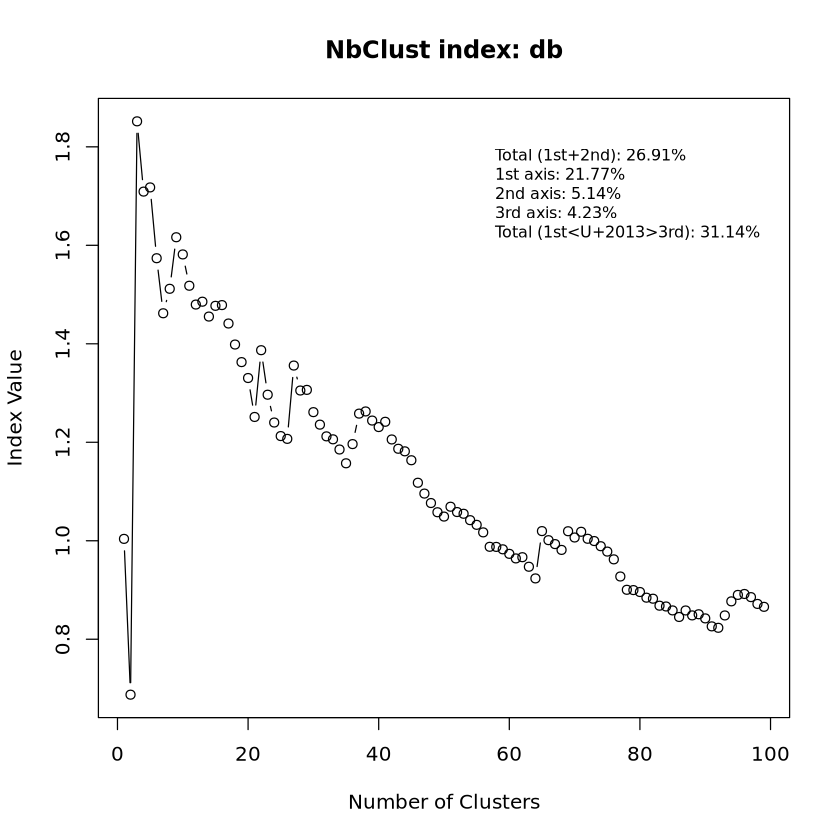

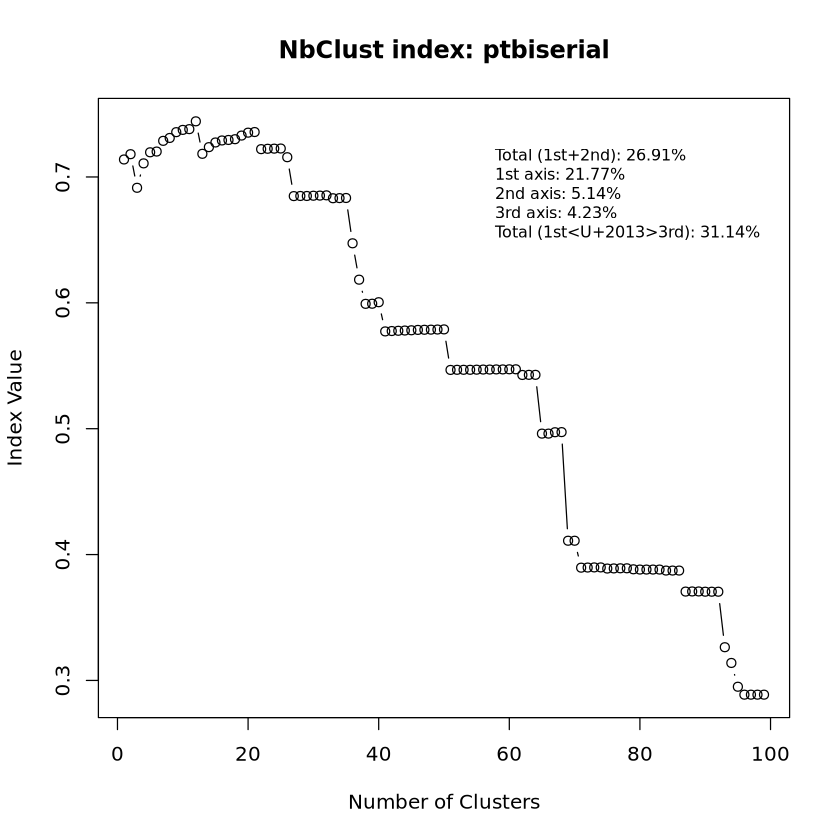

In [46]:
# --- パッケージの読み込み・インストール ---
if (!require(NbClust)) {
  install.packages("NbClust")
  library(NbClust)
}

# --- データの読み込み ---
ifname <- "DataMerge20211220oh_20250717_OH.csv"
readData <- read.delim(ifname, header = TRUE, sep = ",", row.names = 1, as.is = TRUE, strip.white = FALSE)

# --- 目的変数を除外 ---
target_vars <- c("PCEmax", "Jsc", "Voc", "FF")
expl_vars <- readData[, !(colnames(readData) %in% target_vars)]
removed_targets <- colnames(readData)[colnames(readData) %in% target_vars]

# --- 文字列を含む変数を除外（NA以外の文字列） ---
is_char_with_nonNA <- sapply(expl_vars, function(col) {
  any(grepl("[A-Za-z]", col) & col != "NA", na.rm = TRUE)
})
char_vars <- names(expl_vars)[is_char_with_nonNA]
expl_vars_clean <- expl_vars[, !colnames(expl_vars) %in% char_vars]
removed_char_vars <- char_vars

# --- 標準偏差が0の列を除去 ---
sd_nonzero <- apply(expl_vars_clean, 2, sd, na.rm = TRUE) != 0
numData <- expl_vars_clean[, sd_nonzero]
removed_sd_zero <- colnames(expl_vars_clean)[!sd_nonzero]

# --- スケーリング ---
numData_scaled <- scale(numData)

# --- 除去変数の記録と保存 ---
removal_log <- data.frame(
  Step = c(
    rep("Target variable", length(removed_targets)),
    rep("Non-numeric variable", length(removed_char_vars)),
    rep("Zero SD variable", length(removed_sd_zero))
  ),
  Removed_Variable = c(removed_targets, removed_char_vars, removed_sd_zero)
)
write.csv(removal_log, file = "RemovedVariablesSummary.csv", row.names = FALSE)

# --- 相関距離行列の作成 ---
corData <- cor(numData_scaled, use = "pairwise.complete.obs")
corData[is.na(corData)] <- 0
ddata <- dist(1 - abs(corData))  # 相関係数の絶対値で距離定義
ddata_matrix <- as.matrix(ddata)

# --- MDS（主座標分析） ---
Nvars <- ncol(numData)
kmax <- min(Nvars - 1, 100)
if (kmax < 2) stop("⚠️ 変数数が少なすぎてクラスタリングできません")

mdsdata <- cmdscale(ddata, k = kmax, eig = TRUE)

# --- 固有値と累積寄与率の計算 ---
eigvals <- mdsdata$eig
eigvals <- eigvals[eigvals > 0]
eig_ratio <- eigvals / sum(eigvals)
cum_ratio <- cumsum(eig_ratio)

axes_needed_80 <- which(cum_ratio >= 0.80)[1]
cum_contrib_80 <- round(cum_ratio[axes_needed_80] * 100, 2)

cat("✅ 累積寄与率が80%を超えるのに必要な軸数:", axes_needed_80, "軸\n")
cat("📈 累積寄与率:", cum_contrib_80, "%\n")
cat("📊 MDSの軸の数:", ncol(mdsdata$points), "軸\n")

# --- 累積寄与率のプロット ---
plot(cum_ratio * 100, type = "o", pch = 16, col = "blue",
     main = "Cumulative Contribution of MDS Axes",
     xlab = "Number of Axes", ylab = "Cumulative Contribution (%)")
abline(h = 80, col = "red", lty = 2)
abline(v = axes_needed_80, col = "green", lty = 2)
legend("bottomright", legend = paste0(axes_needed_80, " axes = ", cum_contrib_80, "%"),
       bty = "n", cex = 0.8, text.col = "darkgreen")

# --- クラスタリング指標リスト ---
index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")

# --- クラスタリングと出力 ---
for (cindex in index_list) {
  cat("\n🔹 Processing index:", cindex, "\n")

  tryCatch({
    clustEst <- NbClust(
      data = mdsdata$points,
      diss = NULL,
      distance = "euclidean",
      min.nc = 2,
      max.nc = 100,  # クラスタ数の探索範囲
      method = "ward.D2",
      index = cindex
    )

    # --- クラスタ結果の整理 ---
    best_nc <- clustEst$Best.nc[1]
    grpname <- as.factor(clustEst$Best.partition)
    cat(paste0("✅ Best number of clusters (", cindex, ") = ", best_nc, "\n"))

    avg_dist <- rowMeans(ddata_matrix)
    df_cluster_distance <- data.frame(
      Variable = names(grpname),
      Cluster = grpname,
      AvgDistance = avg_dist[names(grpname)],
      MDS1 = round(mdsdata$points[,1][names(grpname)], 2),
      MDS2 = round(mdsdata$points[,2][names(grpname)], 2),
      MDS3 = round(mdsdata$points[,3][names(grpname)], 2)
    )

    # --- CSV出力 ---
    fn <- paste0("New_NbClust_", cindex, "_GrpDist_All_0717_OH_0.8.csv")
    write.csv(df_cluster_distance, file = fn, row.names = FALSE)
    cat("✅ 保存しました: ", fn, "\n")

    # --- スコアプロット（クラスタ数 vs 指標値） ---
    plot(clustEst$All.index, type = "b",
         main = paste("NbClust index:", cindex),
         xlab = "Number of Clusters", ylab = "Index Value")

    # --- 寄与率情報の表示 ---
    p1 <- round(eig_ratio[1] * 100, 2)
    p2 <- round(eig_ratio[2] * 100, 2)
    p3 <- round(eig_ratio[3] * 100, 2)
    p1_2 <- round(p1 + p2, 2)
    p1_3 <- round(p1 + p2 + p3, 2)

    contrib_text <- paste0("Total (1st+2nd): ", p1_2, "%\n",
                           "1st axis: ", p1, "%\n",
                           "2nd axis: ", p2, "%\n",
                           "3rd axis: ", p3, "%\n",
                           "Total (1st–3rd): ", p1_3, "%")
    legend("topright", legend = contrib_text, bty = "n", cex = 0.8)

  }, error = function(e) {
    warning(paste("⚠️ Index", cindex, "failed:", e$message))
  })
}


In [38]:
eigen_vals <- mdsdata$eig
eigen_vals <- eigen_vals[eigen_vals > 0]
cum_ratio <- cumsum(eigen_vals) / sum(eigen_vals)

cat("📈 寄与率（50次元まで）:", round(cum_ratio[3] * 100, 2), "%\n")


<U+0001F4C8> <U+5BC4><U+4E0E><U+7387><U+FF08>50<U+6B21><U+5143><U+307E><U+3067><U+FF09>: 31.15 %


[1] 98.74557

Warning message in cor(numData, use = "pairwise.complete.obs"):
"the standard deviation is zero"


[1] "points" "eig"    "x"      "ac"     "GOF"

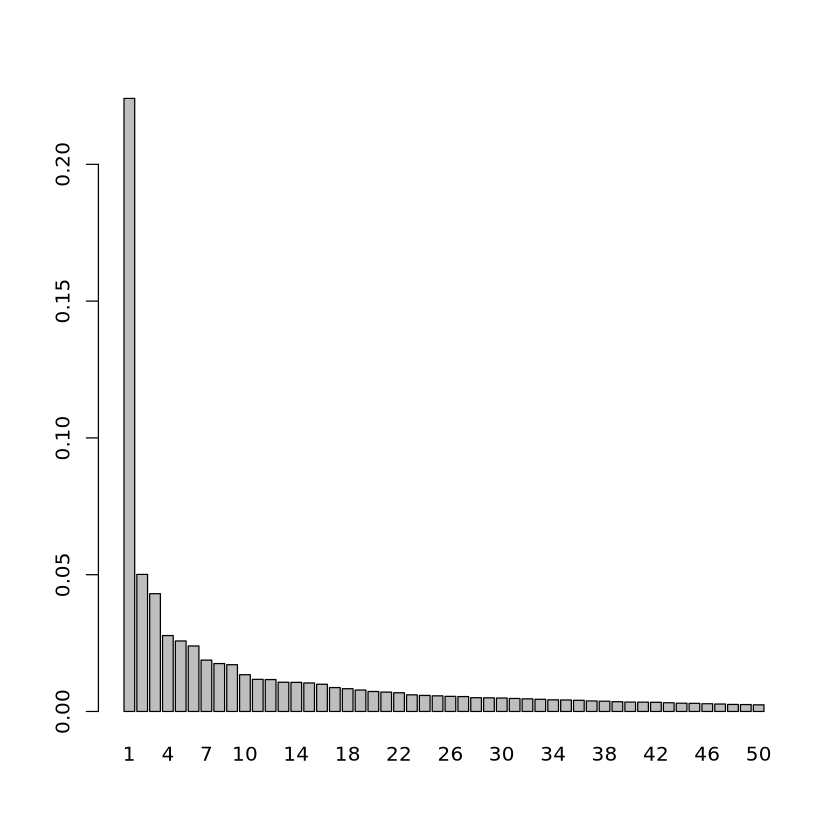

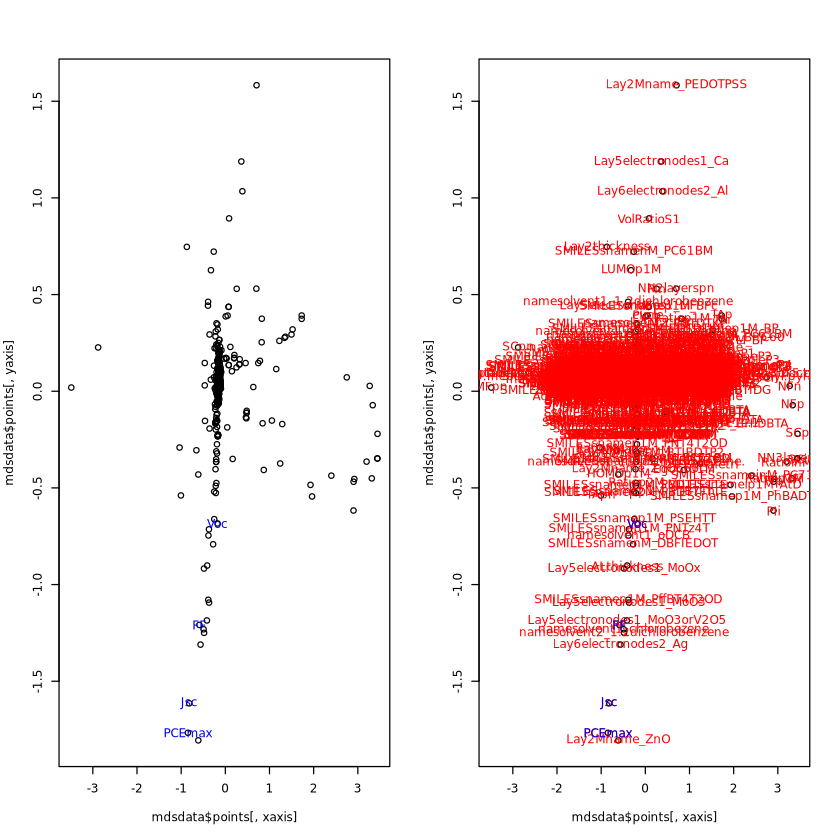

In [11]:
ifname <- "DataMerge20211220oh_20250717_OH.csv"
readData <- read.delim(ifname, header=T,sep=",",row.names=1,as.is=TRUE,strip.white=FALSE)

nf1<-dim(readData)[2]
charaCheck<-rep(FALSE,nf1)
#[1]
for(i in 1:nf1){
  charaCheck[i]<-!is.character(readData[,i])
}
numData<-readData[,charaCheck]
#non NA %
NS<-dim(numData)[1];NF<-dim(numData)[2]
sum(!is.na(numData))/(NS*NF)*100
corData<-cor(numData,use="pairwise.complete.obs")
corData[is.na(corData)==TRUE]<-0
ddata<-dist(1-corData)
#[2]
mdsdata<-cmdscale(ddata,k=5,eig=TRUE)
names(mdsdata)
#[2a]peigen: percent eigen----------------
totaleigen<-sum(mdsdata$eig)
peigen<-mdsdata$eig/totaleigen
barplot(peigen[1:50],names.arg=1:50)
#[2b]-------------------------------------
xaxis<-1
yaxis<-2
par(mfrow=c(1,2))
par(cex=0.6)
#[2c]
ynames<-c("Jsc","Voc","FF","PCEmax")
plot(mdsdata$points[,xaxis],mdsdata$points[,yaxis])
text(mdsdata$points[ynames,xaxis],mdsdata$points[ynames,yaxis],labels=ynames,col="blue")
#[2d]
plot(mdsdata$points[,xaxis],mdsdata$points[,yaxis])
text(mdsdata$points[,xaxis],mdsdata$points[,yaxis],
     labels=rownames(corData),col="red")
text(mdsdata$points[ynames,xaxis],mdsdata$points[ynames,yaxis],
     labels=ynames,col="blue")


Loading required package: RColorBrewer

Warning message in brewer.pal(n = max(as.numeric(grp_factor)), name = "Set2"):
"n too large, allowed maximum for palette Set2 is 8
Returning the palette you asked for with that many colors
"


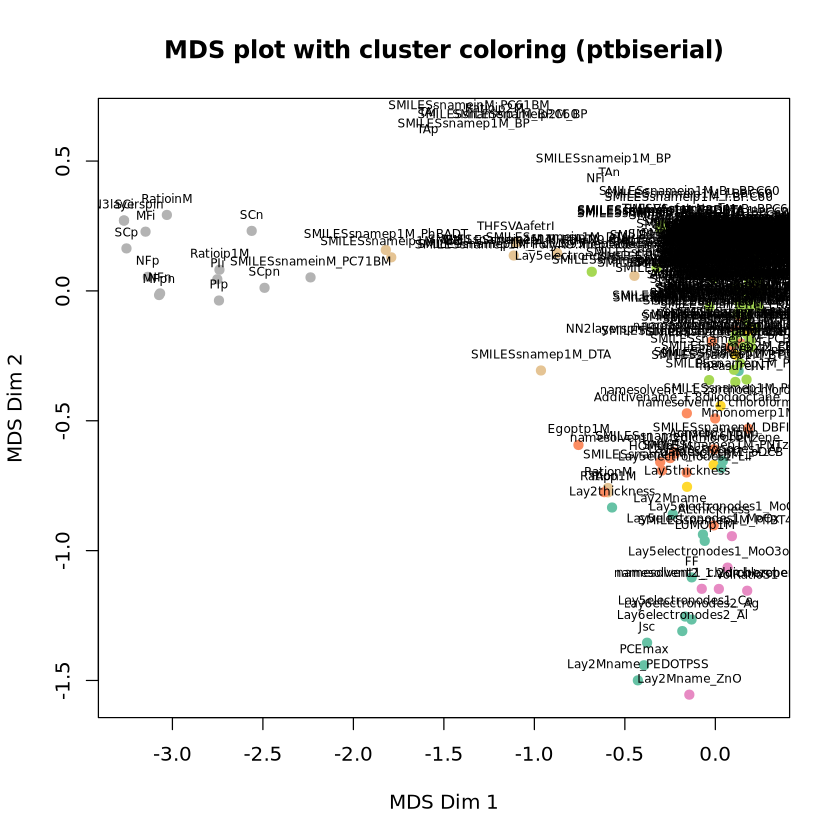

In [16]:
# --- 必要ライブラリ ---
if (!require(RColorBrewer)) install.packages("RColorBrewer")
library(RColorBrewer)

# --- クラスターデータの読み込み ---
grpname <- read.csv("New_NbClust_ptbiserial_Grp_All_0717_OH.csv", row.names = 1)
grp_factor <- as.factor(grpname[, 1])  # 1列目がクラスタラベル

# --- MDSのx軸とy軸の設定 ---
xaxis <- 1
yaxis <- 2

# --- 色の設定（クラスタ数に応じて自動で生成） ---
cluster_colors <- brewer.pal(n = max(as.numeric(grp_factor)), name = "Set2")

# --- MDS プロット（クラスタ色分け） ---
plot(mdsdata$points[, xaxis], mdsdata$points[, yaxis],
     col = cluster_colors[grp_factor],
     pch = 19,
     xlab = paste("MDS Dim", xaxis),
     ylab = paste("MDS Dim", yaxis),
     main = "MDS plot with cluster coloring (ptbiserial)")

# --- オプションでラベル追加（任意） ---
text(mdsdata$points[, xaxis], mdsdata$points[, yaxis],
     labels = rownames(mdsdata$points),
     cex = 0.6, pos = 3)


Warning message in brewer.pal(n = max(n_clusters, 3), name = palette_name):
"n too large, allowed maximum for palette Set3 is 12
Returning the palette you asked for with that many colors
"


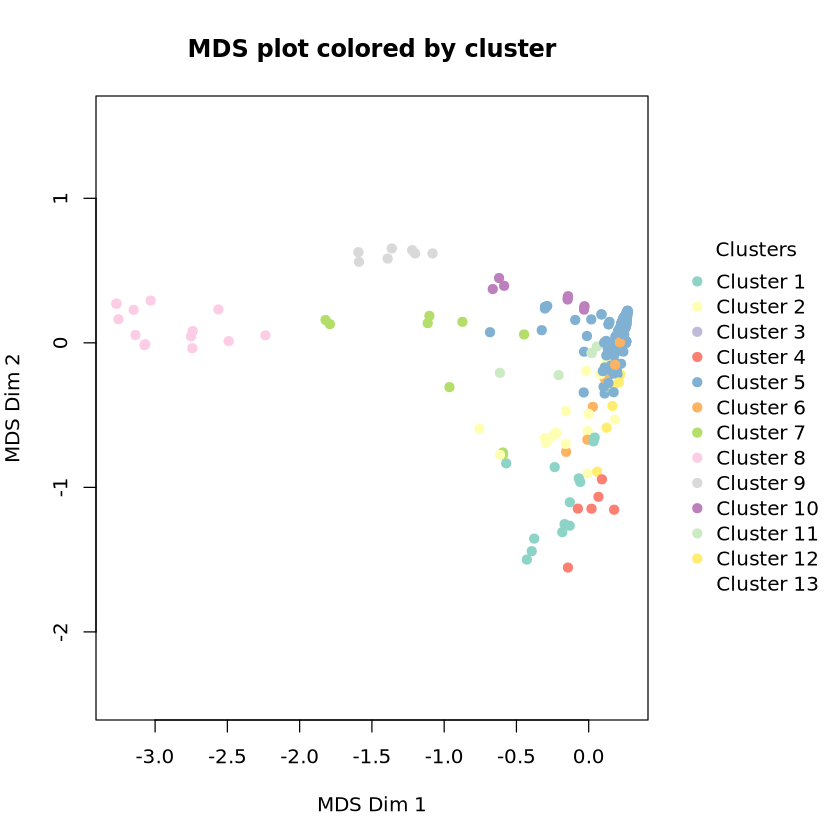

In [20]:
# --- パッケージ ---
library(RColorBrewer)

# --- クラスターデータの読み込み ---
grpname <- read.csv("New_NbClust_ptbiserial_Grp_All_0717_OH.csv", row.names = 1)
grp_factor <- as.factor(grpname[, 1])

# --- 色設定 ---
n_clusters <- length(unique(grp_factor))
palette_name <- ifelse(n_clusters <= 8, "Set2", "Set3")
cluster_colors <- brewer.pal(n = max(n_clusters, 3), name = palette_name)

# --- MDS軸設定 ---
xaxis <- 1
yaxis <- 2

# --- layoutで2パネルに分割（凡例用スペースを確保） ---
layout(matrix(c(1, 2), nrow = 1), widths = c(4, 1))  # 4:1 の比率で分割
par(mar = c(5, 4, 4, 1))  # 左側のパネル（グラフ）の余白

# --- 正方形に保って描画 ---
plot(mdsdata$points[, xaxis], mdsdata$points[, yaxis],
     col = cluster_colors[grp_factor],
     pch = 19,
     xlab = paste("MDS Dim", xaxis),
     ylab = paste("MDS Dim", yaxis),
     main = "MDS plot colored by cluster",
     asp = 1)  # 正方形に保つ

# --- 凡例パネルの描画 ---
par(mar = c(0, 0, 0, 0))
plot.new()
legend("center",
       legend = paste("Cluster", levels(grp_factor)),
       col = cluster_colors[1:n_clusters],
       pch = 19,
       title = "Clusters",
       bty = "n", cex = 1.0)


In [22]:
# t-SNEとUMAP用パッケージ
if (!require(Rtsne)) install.packages("Rtsne")
if (!require(umap)) install.packages("umap")
if (!require(RColorBrewer)) install.packages("RColorBrewer")

library(Rtsne)
library(umap)
library(RColorBrewer)

grpname <- read.csv("New_NbClust_ptbiserial_Grp_All_0717_OH.csv", row.names = 1)
grp_factor <- as.factor(grpname[, 1])
n_clusters <- length(unique(grp_factor))
colors <- brewer.pal(max(n_clusters, 3), "Set2")

set.seed(42)  # 再現性確保
tsne_result <- Rtsne(numData_final, dims = 2, perplexity = 30, verbose = TRUE, max_iter = 1000)

plot(tsne_result$Y,
     col = colors[grp_factor],
     pch = 19,
     asp = 1,
     xlab = "t-SNE 1", ylab = "t-SNE 2",
     main = "t-SNE: Cluster visualization")
legend("topright", legend = paste("Cluster", levels(grp_factor)),
       col = colors, pch = 19, bty = "n")

set.seed(42)
umap_result <- umap(numData_final)

plot(umap_result$layout,
     col = colors[grp_factor],
     pch = 19,
     asp = 1,
     xlab = "UMAP 1", ylab = "UMAP 2",
     main = "UMAP: Cluster visualization")
legend("topright", legend = paste("Cluster", levels(grp_factor)),
       col = colors, pch = 19, bty = "n")


Warning message in brewer.pal(max(n_clusters, 3), "Set2"):
"n too large, allowed maximum for palette Set2 is 8
Returning the palette you asked for with that many colors
"


ERROR: Error in na.fail.default(X): missing values in object


In [24]:
# スケーリング済みデータ（numData_scaled）にNAがないことを確認
numData_scaled_clean <- numData_scaled[complete.cases(numData_scaled), ]

# 対応するクラスタラベルを読み込み
grpname_df <- read.csv("New_NbClust_ptbiserial_Grp_All_0717_OH.csv", row.names = 1)
grpname <- as.factor(grpname_df[rownames(numData_scaled_clean), 1])



In [28]:
library(Rtsne)
set.seed(42)

# サンプル数の確認
n_samples <- nrow(numData_scaled_clean)

# perplexity は n/3 以下で設定
safe_perplexity <- min(30, floor(n_samples / 3))

cat("✅ 使用する perplexity:", safe_perplexity, "\n")

# t-SNE 実行
set.seed(42)
tsne_result <- Rtsne(numData_scaled_clean,
                     dims = 2,
                     perplexity = safe_perplexity,
                     verbose = TRUE,
                     max_iter = 1000)
# 描画
colors <- RColorBrewer::brewer.pal(length(unique(grpname)), "Set2")

plot(tsne_result$Y, col = colors[grpname], pch = 19,
     xlab = "t-SNE 1", ylab = "t-SNE 2", asp = 1, main = "t-SNE: Cluster Visualization")
legend("right", legend = levels(grpname), col = colors, pch = 19, bty = "n", inset = -0.1, xpd = TRUE)


<U+2705> <U+4F7F><U+7528><U+3059><U+308B> perplexity: 24 


ERROR: Error in .check_tsne_params(nrow(X), dims = dims, perplexity = perplexity, : perplexity is too large for the number of samples


ERROR: Error in legend("right", legend = levels(grpname), col = colors, pch = 19, : 'legend' is of length 0


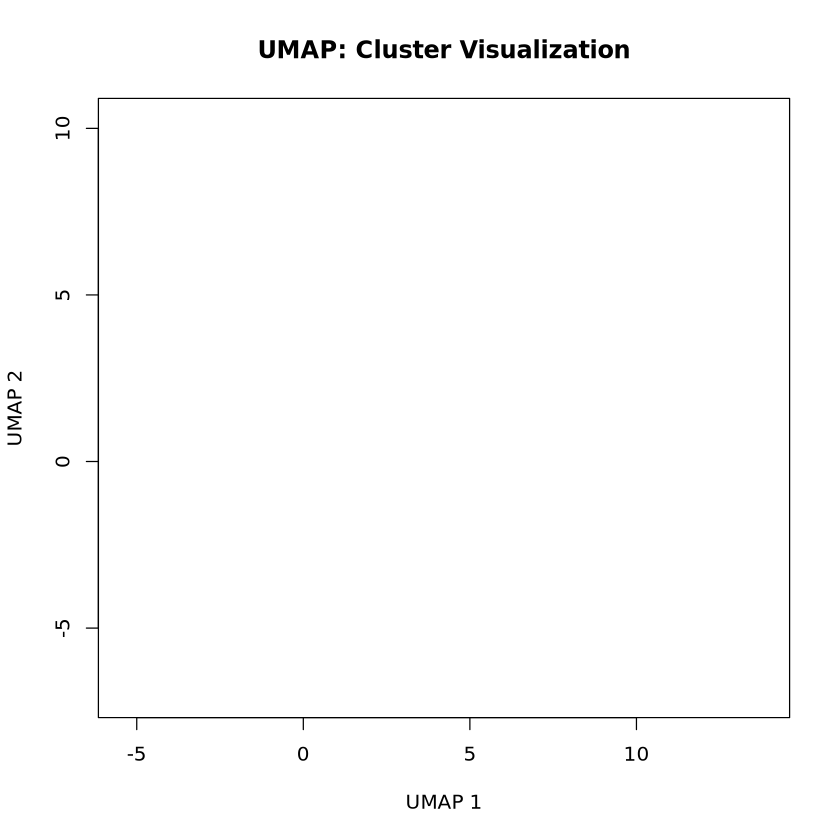

In [26]:
library(umap)

umap_config <- umap.defaults
umap_config$random_state <- 42

umap_result <- umap(numData_scaled_clean, config = umap_config)

# 描画
plot(umap_result$layout, col = colors[grpname], pch = 19,
     xlab = "UMAP 1", ylab = "UMAP 2", asp = 1, main = "UMAP: Cluster Visualization")
legend("right", legend = levels(grpname), col = colors, pch = 19, bty = "n", inset = -0.1, xpd = TRUE)
